Roughly right in spirit, but I'd sharpen it — that phrasing blurs two distinctions that matter, and the imprecision is exactly the kind of thing that gets probed in an interview. Let me tighten it.

**The precise statement:** VoxelNet and PointPillars are **point-cloud encoders** whose job is to convert an unordered, variable-size set of 3D points into a **fixed-size, structured, dense feature grid** that a conventional CNN can process. "Into a BEV map" is *almost* right but conflates two things: (1) the fundamental problem they solve, and (2) the specific output shape, which differs between the two.

Take the pieces apart:

**The real problem they solve is "point cloud → CNN-processable tensor."** A raw point cloud is a set of `(N, 3+)` points — unordered, sparse, and with *N varying per frame*. CNNs need a regular grid (like an image: fixed H×W, dense). You can't convolve over an unordered set. So the encoder's core job is the *conversion*: impose a spatial grid, aggregate the points falling in each cell into a feature vector, and emit a dense tensor. That "make the point cloud look like something a CNN can eat" is the essence — BEV is one *form* that output takes, not the definition of the job.

**Where the two differ — and this is the distinction to get right:**

- **PointPillars — yes, its output is genuinely a BEV pseudo-image.** It divides only the *ground plane* (x-y) into a 2D grid of pillars (infinite-height columns), encodes the points in each pillar into a feature vector, and scatters those into a `(C, H, W)` 2D tensor. That tensor *is* a BEV feature map — a top-down "pseudo-image" — processed by a 2D CNN. So for PointPillars, "maps the point cloud into a BEV map" is accurate.

- **VoxelNet — not directly BEV; it produces a 3D voxel grid first.** VoxelNet divides *3D* space (x-y-**z**) into voxels, encodes points per voxel (its VFE — Voxel Feature Encoding layers), giving a `(C, D, H, W)` **3D** feature volume. That's a voxel grid, *not* a BEV map. It only *becomes* BEV later, when 3D convolutions collapse the height (D) dimension down to a 2D BEV feature map for the detection head. So VoxelNet's *encoder* output is a 3D volume; BEV is a downstream consequence, not the encoder's direct product.

---

Yes — the detection head is part of the model, and the model zoo checkpoint bundles the whole thing together: encoder + backbone + neck + head, all as one trained model with one config. You don't assemble those pieces separately or bolt a head onto a bare encoder — a model zoo entry is the *complete* detector.

Let me be precise about how this is structured, because it clarifies what you're actually downloading:

**A model zoo entry = (config file + checkpoint), and the config defines all the components.** When you grab, say, a CenterPoint checkpoint, the config file describes the full assembly:
- the **encoder** (pillar or voxel — the point-cloud → grid step),
- the **backbone** (2D CNN extracting features from that grid),
- the **neck** (FPN combining multi-scale features),
- the **head** (the detection head predicting boxes).

The checkpoint (`.pth`) holds the trained weights for *all* of those. So the head isn't a separate download — it's one section of the config and one part of the weights, shipped together as an indivisible trained model.

**But here's the distinction your question is circling, and it's worth nailing:** encoder and head are *independent choices*, and the model's *name* usually tells you the head, not the encoder. Recall from earlier — "CenterPoint" refers to the **center-based head**, and it can sit on *either* a pillar or voxel encoder. So:

- **`centerpoint_pillar...`** = center head + pillar encoder.
- **`centerpoint_voxel...`** = center head + voxel encoder.
- **`pointpillars_...`** (the original) = pillar encoder + an *anchor-based* head (not the center head).

So "PointPillars" as a model-zoo name typically means "pillar encoder + anchor head" — the original 2019 architecture. Whereas CenterPoint keeps the option of a pillar encoder but swaps in the center head. The encoder (pillar/voxel) and the head (anchor/center) are the two independent axes, and a given zoo entry has picked one of each and trained them together.


---

## center head:

Here's how the center head is actually structured internally. After the backbone/neck hands it a BEV feature map, the head splits into **multiple parallel prediction branches** (in mmdet3d these are called "task heads" or the separate regression branches), each a small stack of conv layers producing one output map:

- **Heatmap branch** → per-class center locations (the peaks that say "object center here").
- **Regression branches**, computed at each location, predicting:
  - **offset** (sub-pixel refinement of the center, since the grid is coarse),
  - **height/z** (the center's vertical position — the BEV grid lost z, so it's regressed back),
  - **size / dimensions** (l, w, h),
  - **rotation** (yaw, usually as sin/cos),
  - **velocity** (vx, vy — nuScenes-specific, for the mAVE metric).


## After Converting the data using mmdet3d + nuscenes library

- Check the converted data

In [1]:
import pickle

In [2]:
with open("../data/nuscenes_mini/nuscenes_infos_train.pkl", "rb") as infile:
    data = pickle.load(infile)

In [3]:
type(data), data.keys(), len(data["metainfo"]), len(data["data_list"])

(dict, dict_keys(['metainfo', 'data_list']), 4, 323)

In [4]:
data["metainfo"].keys()

dict_keys(['categories', 'dataset', 'version', 'info_version'])

In [5]:
data["metainfo"]["version"]

'v1.0-mini'

In [6]:
data["metainfo"]["dataset"]

'nuscenes'

In [7]:
data["metainfo"]["categories"]

{'car': 0,
 'truck': 1,
 'trailer': 2,
 'bus': 3,
 'construction_vehicle': 4,
 'bicycle': 5,
 'motorcycle': 6,
 'pedestrian': 7,
 'traffic_cone': 8,
 'barrier': 9}

In [8]:
sample_50 = data["data_list"][50]
sample_50.keys()

dict_keys(['sample_idx', 'token', 'timestamp', 'ego2global', 'images', 'lidar_points', 'lidar_sweeps', 'instances', 'cam_instances'])

In [9]:
len(sample_50["lidar_sweeps"])

10

In [10]:
sample_50["lidar_sweeps"][0]

{'timestamp': 1535489301.496785,
 'ego2global': [[-0.7467848658561707,
   -0.6650575399398804,
   -0.0032923484686762094,
   1316.378173828125],
  [0.6649891138076782,
   -0.7466146945953369,
   -0.018867526203393936,
   1038.5936279296875],
  [0.010089874267578125, -0.01627935841679573, 0.9998165965080261, 0.0],
  [0.0, 0.0, 0.0, 1.0]],
 'lidar_points': {'num_pts_feats': None,
  'lidar_path': './data/nuscenes/sweeps/LIDAR_TOP/n008-2018-08-28-16-43-51-0400__LIDAR_TOP__1535489301496785.pcd.bin',
  'lidar2ego': [[-0.0005427949945442379,
    0.9989306926727295,
    0.046229466795921326,
    0.9857929944992065],
   [-0.9999954700469971, -0.0004056931647937745, -0.0029750114772468805, 0.0],
   [-0.002953075338155031,
    -0.046230874955654144,
    0.9989264011383057,
    1.840190052986145],
   [0.0, 0.0, 0.0, 1.0]],
  'lidar2sensor': [[1.0,
    3.686228637889144e-07,
    -1.0879319233936258e-05,
    -2.0054156266269274e-05],
   [-3.6855419693893055e-07,
    1.0,
    6.311094693955965e-06,
 

In [8]:
sample = data["data_list"][0]

In [9]:
sample.keys()

dict_keys(['sample_idx', 'token', 'timestamp', 'ego2global', 'images', 'lidar_points', 'instances', 'cam_instances'])

In [27]:
len(sample["instances"]), sample["instances"][0].keys()

(69,
 dict_keys(['bbox_label', 'bbox_3d', 'bbox_3d_isvalid', 'bbox_label_3d', 'num_lidar_pts', 'num_radar_pts', 'velocity']))

In [18]:
sample["lidar_points"]

{'num_pts_feats': 5,
 'lidar_path': 'n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin',
 'lidar2ego': [[0.0020332718268036842,
   0.9997040629386902,
   0.024241721257567406,
   0.9437130093574524],
  [-0.9999805092811584, 0.0021756570786237717, -0.00584863917902112, 0.0],
  [-0.005899650044739246,
   -0.02422935888171196,
   0.9996890425682068,
   1.8402299880981445],
  [0.0, 0.0, 0.0, 1.0]]}

In [19]:
sample["images"]

{'CAM_FRONT': {'img_path': 'n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg',
  'cam2img': [[1266.417203046554, 0.0, 816.2670197447984],
   [0.0, 1266.417203046554, 491.50706579294757],
   [0.0, 0.0, 1.0]],
  'cam2ego': [[0.005684778559952974,
    -0.005636667832732201,
    0.9999679327011108,
    1.7007912397384644],
   [-0.9999834895133972,
    -0.0008371152798645198,
    0.0056801484897732735,
    0.01594563201069832],
   [0.000805071322247386,
    -0.9999837875366211,
    -0.005641333758831024,
    1.5109575986862183],
   [0.0, 0.0, 0.0, 1.0]],
  'sample_data_token': 'e3d495d4ac534d54b321f50006683844',
  'timestamp': 1532402927.61246,
  'lidar2cam': [[0.9999702572822571,
    0.003407371463254094,
    0.0069207423366606236,
    0.01687305048108101],
   [0.006852706428617239,
    0.019589632749557495,
    -0.9997846484184265,
    -0.32902389764785767],
   [-0.0035422123037278652,
    0.99980229139328,
    0.019565701484680176,
    -0.4292221665382385],
   [0.0, 0.0, 0.

In [16]:
sample["ego2global"]

[[-0.345552921295166,
  0.9382579922676086,
  0.016282515600323677,
  411.3039245605469],
 [-0.9383381009101868,
  -0.34528031945228577,
  -0.01740977168083191,
  1180.890380859375],
 [-0.010712824761867523, -0.021294502541422844, 0.9997158646583557, 0.0],
 [0.0, 0.0, 0.0, 1.0]]

In [10]:
sample["lidar_points"].keys()

dict_keys(['num_pts_feats', 'lidar_path', 'lidar2ego'])

In [11]:
len(sample['instances'])

69

In [12]:
sample

{'sample_idx': 0,
 'token': 'ca9a282c9e77460f8360f564131a8af5',
 'timestamp': 1532402927.647951,
 'ego2global': [[-0.345552921295166,
   0.9382579922676086,
   0.016282515600323677,
   411.3039245605469],
  [-0.9383381009101868,
   -0.34528031945228577,
   -0.01740977168083191,
   1180.890380859375],
  [-0.010712824761867523, -0.021294502541422844, 0.9997158646583557, 0.0],
  [0.0, 0.0, 0.0, 1.0]],
 'images': {'CAM_FRONT': {'img_path': 'n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg',
   'cam2img': [[1266.417203046554, 0.0, 816.2670197447984],
    [0.0, 1266.417203046554, 491.50706579294757],
    [0.0, 0.0, 1.0]],
   'cam2ego': [[0.005684778559952974,
     -0.005636667832732201,
     0.9999679327011108,
     1.7007912397384644],
    [-0.9999834895133972,
     -0.0008371152798645198,
     0.0056801484897732735,
     0.01594563201069832],
    [0.000805071322247386,
     -0.9999837875366211,
     -0.005641333758831024,
     1.5109575986862183],
    [0.0, 0.0, 0.0, 1.0]],
 

# Eval results

## NMS (Non-Maximum Suppression)

NMS is a post-processing step that **removes duplicate detections of the same object.** The problem it solves: a detector often fires *multiple* overlapping boxes for one object — several anchors near the same car all say "car here," producing a cluster of near-identical boxes. You want *one* box per object, not five stacked on top of each other. NMS prunes the redundant ones.

How it works, simply:
1. Take all predicted boxes, sort by confidence score.
2. Keep the highest-scoring box.
3. Remove any other box that **overlaps it too much** (above an IoU threshold) — those are considered duplicates of the same object.
4. Repeat with the next-highest remaining box until none are left.

So "non-maximum suppression" = suppress (remove) the non-maximum (lower-scoring) boxes among a cluster of overlapping ones, keeping only the local maximum. The result: one box per object instead of a pile. In your PointPillars pipeline, NMS runs after the anchor head — it's why the ~220 raw predictions aren't *even more* numerous (NMS already removed the worst overlaps; the 220 are what survived, still including many low-confidence non-overlapping candidates).

## Precision-Recall curve (with the ROC contrast)

Since you know ROC, the fastest way in is by contrast — they're close cousins, both made by sweeping a threshold, but they plot different axes and suit different situations.

**ROC recap:** you sweep the classifier's threshold and plot **True Positive Rate (recall)** on the y-axis against **False Positive Rate** on the x-axis. Area under it = AUC.

**PR curve:** you sweep the same threshold, but plot **Precision** (y) against **Recall** (x). So the difference is the x-axis / what's on each axis:

- **Recall** = TP / (TP + FN) = "of all real objects, what fraction did I find?" (Same as ROC's TPR.)
- **Precision** = TP / (TP + FP) = "of all my positive predictions, what fraction were correct?"

The key structural difference: **ROC's x-axis (FPR) involves true negatives; PR's axes do not.** FPR = FP / (FP + TN). Precision = TP / (TP + FP). Precision has *no TN term*. This is exactly why PR curves are preferred for **detection** and **imbalanced** problems, and it's the reason to understand them for your work:

**Why PR, not ROC, for object detection.** In detection there's no meaningful "true negative." A true negative would be "correctly predicting no object" — but at how many of the *infinite* possible box locations? The number of TNs is ill-defined/enormous. ROC's FPR needs TN, so it doesn't fit detection cleanly. Precision sidesteps this entirely — it only cares about your *predictions* (TP vs FP among boxes you emitted), not the vast empty background. So PR is the natural fit.

**Why PR for imbalance.** When positives are rare (few objects among huge background — exactly detection), ROC can look misleadingly good: a large TN count makes FPR stay low even with many false positives, so the ROC curve hugs the top-left and AUC looks high. PR is more honest here — precision drops visibly when you accumulate false positives, because there's no giant TN denominator masking them. So PR gives a truer picture when positives are scarce.

**Reading the PR curve** (tie it to your 220-predictions example):
- Rank all predictions by score, sweep the threshold from strict to lenient.
- <mark>**Strict threshold**</mark> (only top-confidence boxes): <mark>high precision</mark> (they're usually right), <mark>low recall</mark> (you've committed to few, missing many real objects). → top-left region.
- **Lenient threshold** (include the low-confidence tail of your 220): recall climbs (you catch more real objects) but precision falls (the low-confidence boxes are mostly false positives). → bottom-right region.
- The curve traces this tradeoff. A **good** detector keeps precision high *even as recall increases* — it finds most objects without flooding false positives — so its curve stays high and to the right, enclosing a **large area**.

**AP = area under the PR curve** (from the earlier discussion). So AP summarizes the whole precision-recall tradeoff into one number, exactly analogous to how AUC summarizes ROC. Your barrier class had precision = 0 at every recall → the PR curve sits on the floor → area 0 → AP 0.000. Your car class (AP 0.866) has a PR curve that stays high across most of the recall range.

The clean mental mapping from what you know:
- **ROC ↔ PR**: both sweep a threshold; ROC plots TPR vs FPR (AUC), PR plots precision vs recall (AP).
- **Use ROC** when classes are balanced and TN is meaningful.
- **Use PR** when positives are rare or TN is ill-defined — **detection is the poster child**, which is why nuScenes (and all object detection) reports AP/mAP from PR curves, not AUC from ROC.

So: NMS removes duplicate overlapping boxes (one per object); the PR curve is ROC's cousin that plots precision vs recall instead of TPR vs FPR, preferred for detection because it ignores the ill-defined true-negative background and stays honest under class imbalance — and its area is the AP you've been looking at. Those `plots/` files from your eval run are literally these PR curves per class; now you can read them.


---


Three good questions, and the third one catches a genuine ambiguity — there are **two different thresholds** in play and you're right that they're not the same thing. Let me sort all three out.

**1. Does the model output a score?** Yes. Every predicted box comes with a **confidence score** (in your predictions JSON it's the `detection_score` field). That's the model saying how sure it is that this box is a real object of that class. This is the score that gets swept to build the PR curve, and the one you'd filter on for visualization. So yes — each of your 220 predictions has a score attached.

**2. Does AP stand for "Average Precision" or "Area under Precision curve"?** Officially, **Average Precision.** But here's why your confusion is completely reasonable: the two are *nearly the same thing* numerically. AP is formally defined as the **average of precision values across recall levels** — and averaging precision over all recall levels *is* essentially computing the area under the precision-recall curve. So:

- **Name:** Average Precision.
- **What it computes:** the area under the PR curve (approximately — it's the mean precision sampled across recall points, which approximates the integral/area).

So both descriptions point at the same quantity; "Average Precision" is the correct name, and "area under the PR curve" is an accurate description of what that average represents. You'll see people use them interchangeably. Not wrong to think of it as area — just know the letters stand for *Average Precision*.

**3. The two thresholds — you're exactly right, they're different.** This is the sharp catch. There are indeed **two distinct thresholds**, and conflating them is a common confusion:

**Threshold A — the confidence/score threshold (what I was describing for the PR curve).** This is swept over the *model's confidence scores* to trace the precision-recall curve. Strict = only high-confidence predictions; lenient = include low-confidence ones. Sweeping *this* is how you get precision and recall at different operating points, producing the PR curve whose area is AP. This threshold is *internal to computing a single AP*.

**Threshold B — the matching distance threshold (0.5, 1, 2, 4 m).** This is completely different. It defines **what counts as a correct match** between a prediction and a ground-truth box. Recall nuScenes uses **center distance** (not IoU) to decide if a prediction matches a GT object: a prediction is a "true positive" if its center is within *this distance* of a GT center. So:
- At **0.5 m**, matching is strict — the prediction's center must be very close to be counted correct.
- At **4 m**, matching is lenient — a prediction within 4 m of a GT center counts as a hit.

So your instinct is right but let me refine it: the four distance thresholds (0.5/1/2/4 m) are **not** the confidence threshold, and they're **not** just for mAP. Here's the precise structure:

- For **each distance threshold**, you compute a **separate AP** by sweeping the *confidence* threshold (threshold A) and taking the PR-curve area. So "barrier AP @ 0.5m" is a full AP computed with strict 0.5m matching; "barrier AP @ 4m" is a full AP computed with lenient 4m matching. That's why metrics_summary shows **4 AP values per class** — one PR-curve-area per distance threshold.
- The **per-class AP** is then the **average of those 4** distance-threshold APs.
- **mAP** is the mean of the per-class APs across all 10 classes.

So both thresholds are always in play:
- **Confidence threshold (A):** swept *inside* each AP computation to build the PR curve. Always active, for every AP.
- **Distance threshold (B):** determines the matching strictness; nuScenes computes AP at *four* of these and averages, which is why you see four numbers per class.

To correct your framing slightly: the distance thresholds aren't "only for mAP" — they produce the four per-class AP values that get averaged into the *single* per-class AP, which then averages into mAP. And the confidence threshold I described for the PR curve is a *third*, separate mechanism operating inside each of those four AP computations. So there are genuinely two threshold types, both essential, at different levels:

```
mAP  =  mean over classes of:
          per-class AP  =  mean over 4 distance thresholds of:
              AP @ distance d  =  area under PR curve, where the PR curve
                                  is traced by sweeping the CONFIDENCE threshold,
                                  and "match" is defined by distance d
```

So: yes, the model outputs a score (`detection_score`); AP = Average Precision (which equals the PR-curve area); and you're correct that the 0.5/1/2/4m values are a *different* threshold from the confidence one — they're the *matching-distance* thresholds, one AP computed per distance, averaged into the per-class AP, then into mAP. The confidence threshold is the one swept *within* each of those to build the curve.

---

## Detection Domain (BEV grid; at Anchors)

Great question — this gets at what the network *physically* produces before it becomes boxes, and the answer for your PointPillars (anchor-based, BEV) model is: **the output lives on the 2D BEV grid, one set of predictions per grid cell (per anchor at each cell).** Not per voxel, not per point — per **BEV spatial location**. Let me trace it precisely, because the domain of the output is exactly the pillar/BEV structure you've been learning.

**The output domain is the BEV feature map's spatial grid.** Recall the PointPillars data flow: pillars → scatter into a 2D BEV pseudo-image → 2D CNN backbone → FPN neck → **detection head**. By the time you reach the head, the feature map is a 2D grid, `(C, H, W)` — H×W spatial cells covering the ground plane (the `point_cloud_range` divided by the effective stride). The head's outputs are produced **at each of these H×W cells**. So the domain is the **BEV grid**: every spatial location gets predictions.

**What comes out at each cell — and the anchor structure.** At each BEV cell, the anchor head places a small number of **anchors** (preset template boxes — for nuScenes typically a couple of orientations/sizes per class). For *each anchor at each cell*, the head outputs three things (the parallel conv branches from the head):

1. **Classification scores** — one per class (is there a car / pedestrian / … here?). This is where the `detection_score` originates.
2. **Box regression** — the 7 (or 9, with velocity) offsets from the anchor: Δx, Δy, Δz, Δw, Δl, Δh, Δyaw (+ vx, vy). "Adjust this anchor by these amounts to fit the actual object."
3. **Direction classification** — the heading-flip resolver.

So the raw output is a **dense tensor over the BEV grid**: shape roughly `(H, W, num_anchors, [class_scores + box_deltas + direction])`. Every cell, every anchor, gets a full prediction. That's why there are so *many* raw predictions before filtering — H×W×num_anchors is thousands of candidate boxes, most low-confidence.


---


## Anchors

- Note: The grid covers, say, **±50 m** in x and y, divided into a fine grid — after the backbone stride, cells correspond to maybe **~0.5–1 m** of physical space each.

An anchor is a **preset template box** — a "guess" of a typical object's size and orientation, placed at a location, that the network *refines* rather than predicting a box from scratch. The core idea: instead of asking the network "what box is here?" (hard — infinite possible boxes), you ask "here's a template box; how do I *adjust* it to fit the actual object?" (easier — just predict small corrections). Anchors give the network a **reference frame** to predict *relative* to.

**Concretely for your PointPillars on nuScenes:** at every BEV grid cell, you place a few anchors. Each anchor is a box with a **predefined size and orientation** — e.g., "a car-sized box (4.6m × 1.9m × 1.7m) at 0°" and "the same car-sized box at 90°." Recall the config's `anchor_generator` block you saw — it listed `sizes` and `rotations`. Those *are* the anchor definitions: the preset dimensions and angles. So the anchors are literally specified in the config: a set of template boxes of typical object sizes, at a couple of orientations, tiled across every grid cell.

**Why they exist — the problem they solve:** predicting a 3D box means outputting 7 continuous numbers (x,y,z,w,l,h,yaw) that could be anything. Regressing arbitrary values from scratch is unstable and hard to learn. Anchors constrain the problem: 
- The anchor provides a **starting box** (right ballpark size for a car).
- The network only predicts **small offsets** from it (Δx, Δy, Δsize, Δyaw) — "shift the car-box a bit left, make it slightly bigger, rotate 5°."
- Predicting small corrections to a sensible starting point is much easier to learn than predicting absolute boxes.

**How anchors are used, step by step:**
1. Define anchors: a few template boxes (per size/orientation) at every BEV cell. For a grid of H×W cells with, say, 2 anchors each, that's H×W×2 anchor boxes covering the scene.
2. For each anchor, the head predicts: (a) is there a real object matching this anchor? (classification score), and (b) the offset to adjust this anchor to the true box (regression).
3. Decode: anchor + predicted offset = final box.
4. Threshold + NMS to get the sparse final set.

**The analogy that usually lands:** anchors are like **pre-drawn stencils** laid over the scene. At each spot, you have a "car stencil" and a few others. The network's job isn't to draw a box freehand — it's to say "yes, a car matches this stencil here, nudged slightly this way" or "no object matching this stencil here." Predicting *against stencils* is easier than freehand.

**Why they can be a weakness (ties to the anchor-vs-center discussion):** you have to *pre-design* the anchors — pick sizes, orientations, how many. Get them wrong (an object much bigger/smaller/differently-oriented than any anchor) and detection suffers. nuScenes' 10 classes have wildly different sizes (pedestrian vs. bus), needing carefully chosen anchors per class. This hyperparameter burden is exactly what **center-based** heads (CenterPoint) eliminate — they predict object centers directly (no templates), sidestepping anchor design. So "anchor-based" (your PointPillars) = predict offsets from preset template boxes; "center-based" (CenterPoint) = predict centers directly, no templates. Same output domain (BEV grid), different parameterization.

---

## Output

**At the network's raw output:** yes, there's a score *per class* per anchor. Recall the classification branch outputs `num_classes` sigmoid scores at each cell/anchor — so for this location, the network computed a car score, a truck score, a pedestrian score, etc. (10 scores, one per class). Each is an independent "is this class present here?" probability.

**In this final detection record:** no — you see only *one* score and *one* `detection_name`. What happened is that the post-processing **collapsed the per-class scores into a single winning class**. For this box, `car` had the highest score (0.905), so the pipeline: took the max (or thresholded) across the per-class scores, assigned the box to the winning class (`car`), and reported that class's score as `detection_score`. The other 9 classes' scores for this box aren't in the output — they were lower, the box was committed to `car`, and only the winning class + its score survive into the final record.

So the relationship:
- **Network output:** 10 sigmoid scores (one per class) per anchor — the full per-class picture.
- **After argmax/decode:** each surviving box keeps only its *winning* class name and that class's score. → what you see: `detection_name: 'car'`, `detection_score: 0.905`.



In [33]:
import json

In [38]:
with open("../results/pointpillars_fpn/preds/pred_instances_3d/metrics_summary.json", "rb") as infile:
    metrics_summary = json.load(infile)

In [40]:
metrics_summary.keys()

dict_keys(['label_aps', 'mean_dist_aps', 'mean_ap', 'label_tp_errors', 'tp_errors', 'tp_scores', 'nd_score', 'eval_time', 'cfg', 'meta'])

In [39]:
metrics_summary

{'label_aps': {'car': {'0.5': 0.7340303780392284,
   '1.0': 0.8744210584454354,
   '2.0': 0.9211355709443746,
   '4.0': 0.9328556090350786},
  'truck': {'0.5': 0.515799971915575,
   '1.0': 0.6094698867743235,
   '2.0': 0.6289079045934317,
   '4.0': 0.6326162403733621},
  'bus': {'0.5': 0.514106156991057,
   '1.0': 0.9087547344538155,
   '2.0': 0.9798138907864473,
   '4.0': 0.9798138907864473},
  'trailer': {'0.5': 0.0, '1.0': 0.0, '2.0': 0.0, '4.0': 0.0},
  'construction_vehicle': {'0.5': 0.0, '1.0': 0.0, '2.0': 0.0, '4.0': 0.0},
  'pedestrian': {'0.5': 0.7632486873214451,
   '1.0': 0.7780789097190032,
   '2.0': 0.795559022797466,
   '4.0': 0.8330171365489853},
  'motorcycle': {'0.5': 0.30354343213271073,
   '1.0': 0.3612581569728797,
   '2.0': 0.3937638707291824,
   '4.0': 0.43430407739925436},
  'bicycle': {'0.5': 0.21534668485724642,
   '1.0': 0.3016515367003226,
   '2.0': 0.3016515367003226,
   '4.0': 0.30636534472834676},
  'traffic_cone': {'0.5': 0.002523956972658548,
   '1.0': 0

In [47]:
val_data = pickle.load(open("../data/nuscenes/nuscenes_infos_val.pkl", "rb"))

In [83]:
len(val_data["data_list"])

81

In [50]:
val_data["data_list"][1].keys()

dict_keys(['sample_idx', 'token', 'timestamp', 'ego2global', 'images', 'lidar_points', 'lidar_sweeps', 'instances', 'cam_instances'])

In [55]:
val_data["data_list"][1]["instances"][0].keys()

dict_keys(['bbox_label', 'bbox_3d', 'bbox_3d_isvalid', 'bbox_label_3d', 'num_lidar_pts', 'num_radar_pts', 'velocity'])

In [65]:
val_data["data_list"][1].keys()

dict_keys(['sample_idx', 'token', 'timestamp', 'ego2global', 'images', 'lidar_points', 'lidar_sweeps', 'instances', 'cam_instances'])

In [77]:
len(val_data["data_list"][1]["instances"])

30

In [56]:
val_data["data_list"][1]["instances"][0]

{'bbox_label': 7,
 'bbox_3d': [-8.707405554968487,
  31.974384439635898,
  -0.017067512780955987,
  0.647,
  0.621,
  1.778,
  -1.7558828678553826],
 'bbox_3d_isvalid': True,
 'bbox_label_3d': 7,
 'num_lidar_pts': 2,
 'num_radar_pts': 1,
 'velocity': [-0.15486453092360253, -1.0405923117004867]}

In [66]:
val_data["data_list"][1]["token"]

'3950bd41f74548429c0f7700ff3d8269'

In [58]:
results = json.load(open("../results/pointpillars_fpn/preds/pred_instances_3d/results_nusc.json"))

In [61]:
results.keys()

dict_keys(['meta', 'results'])

In [79]:
len(results["results"][val_data["data_list"][1]["token"]])

220

In [80]:
results["results"][val_data["data_list"][1]["token"]][0]

{'sample_token': '3950bd41f74548429c0f7700ff3d8269',
 'translation': [587.3458694908957, 1654.4410196149427, 1.1896295283788167],
 'size': [1.923728108406067, 4.5969319343566895, 1.6218929290771484],
 'rotation': [-0.9673922360685304,
  -0.011049852722707525,
  -0.029929918761016513,
  0.2512655215346794],
 'velocity': [8.010351344448372, -4.386880227192237],
 'detection_name': 'car',
 'detection_score': 0.9053400754928589,
 'attribute_name': 'vehicle.moving'}

In [74]:
ls = []
for item in results["results"][val_data["data_list"][1]["token"]]:
    ls.append(item["detection_name"])

In [75]:
import numpy as np

In [76]:
np.unique(ls)

array(['barrier', 'bicycle', 'bus', 'car', 'construction_vehicle',
       'motorcycle', 'pedestrian', 'traffic_cone', 'trailer', 'truck'],
      dtype='<U20')

In [41]:
with open("../results/pointpillars_fpn/preds/pred_instances_3d/metrics_details.json", "rb") as infile:
    metrics_details = json.load(infile)

In [42]:
metrics_details.keys()

dict_keys(['car:0.5', 'car:1.0', 'car:2.0', 'car:4.0', 'truck:0.5', 'truck:1.0', 'truck:2.0', 'truck:4.0', 'bus:0.5', 'bus:1.0', 'bus:2.0', 'bus:4.0', 'trailer:0.5', 'trailer:1.0', 'trailer:2.0', 'trailer:4.0', 'construction_vehicle:0.5', 'construction_vehicle:1.0', 'construction_vehicle:2.0', 'construction_vehicle:4.0', 'pedestrian:0.5', 'pedestrian:1.0', 'pedestrian:2.0', 'pedestrian:4.0', 'motorcycle:0.5', 'motorcycle:1.0', 'motorcycle:2.0', 'motorcycle:4.0', 'bicycle:0.5', 'bicycle:1.0', 'bicycle:2.0', 'bicycle:4.0', 'traffic_cone:0.5', 'traffic_cone:1.0', 'traffic_cone:2.0', 'traffic_cone:4.0', 'barrier:0.5', 'barrier:1.0', 'barrier:2.0', 'barrier:4.0'])

In [44]:
len(metrics_details)

40

In [81]:
metrics_details["barrier:0.5"].keys()

dict_keys(['recall', 'precision', 'confidence', 'trans_err', 'vel_err', 'scale_err', 'orient_err', 'attr_err'])

In [45]:
metrics_details["barrier:0.5"]

{'recall': [0.0,
  0.01,
  0.02,
  0.03,
  0.04,
  0.05,
  0.06,
  0.07,
  0.08,
  0.09,
  0.1,
  0.11,
  0.12,
  0.13,
  0.14,
  0.15,
  0.16,
  0.17,
  0.18,
  0.19,
  0.2,
  0.21,
  0.22,
  0.23,
  0.24,
  0.25,
  0.26,
  0.27,
  0.28,
  0.29,
  0.3,
  0.31,
  0.32,
  0.33,
  0.34,
  0.35000000000000003,
  0.36,
  0.37,
  0.38,
  0.39,
  0.4,
  0.41000000000000003,
  0.42,
  0.43,
  0.44,
  0.45,
  0.46,
  0.47000000000000003,
  0.48,
  0.49,
  0.5,
  0.51,
  0.52,
  0.53,
  0.54,
  0.55,
  0.56,
  0.5700000000000001,
  0.58,
  0.59,
  0.6,
  0.61,
  0.62,
  0.63,
  0.64,
  0.65,
  0.66,
  0.67,
  0.68,
  0.6900000000000001,
  0.7000000000000001,
  0.71,
  0.72,
  0.73,
  0.74,
  0.75,
  0.76,
  0.77,
  0.78,
  0.79,
  0.8,
  0.81,
  0.8200000000000001,
  0.8300000000000001,
  0.84,
  0.85,
  0.86,
  0.87,
  0.88,
  0.89,
  0.9,
  0.91,
  0.92,
  0.93,
  0.9400000000000001,
  0.9500000000000001,
  0.96,
  0.97,
  0.98,
  0.99,
  1.0],
 'precision': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,


In [43]:
metrics_details

{'car:0.5': {'recall': [0.0,
   0.01,
   0.02,
   0.03,
   0.04,
   0.05,
   0.06,
   0.07,
   0.08,
   0.09,
   0.1,
   0.11,
   0.12,
   0.13,
   0.14,
   0.15,
   0.16,
   0.17,
   0.18,
   0.19,
   0.2,
   0.21,
   0.22,
   0.23,
   0.24,
   0.25,
   0.26,
   0.27,
   0.28,
   0.29,
   0.3,
   0.31,
   0.32,
   0.33,
   0.34,
   0.35000000000000003,
   0.36,
   0.37,
   0.38,
   0.39,
   0.4,
   0.41000000000000003,
   0.42,
   0.43,
   0.44,
   0.45,
   0.46,
   0.47000000000000003,
   0.48,
   0.49,
   0.5,
   0.51,
   0.52,
   0.53,
   0.54,
   0.55,
   0.56,
   0.5700000000000001,
   0.58,
   0.59,
   0.6,
   0.61,
   0.62,
   0.63,
   0.64,
   0.65,
   0.66,
   0.67,
   0.68,
   0.6900000000000001,
   0.7000000000000001,
   0.71,
   0.72,
   0.73,
   0.74,
   0.75,
   0.76,
   0.77,
   0.78,
   0.79,
   0.8,
   0.81,
   0.8200000000000001,
   0.8300000000000001,
   0.84,
   0.85,
   0.86,
   0.87,
   0.88,
   0.89,
   0.9,
   0.91,
   0.92,
   0.93,
   0.9400000000000001,
   0

# Visualize detection vs GT

## BEV

---


- The annotation boxes are upright (yaw only) in the global frame
- But in the ego and LiDAR frame it is not yaw only (has small roll/pitch)
    - It can be ignored

---

- **bbox_3d**:
    - 'bbox_3d': [-11.446511203640204, 11.80850512968282, -0.16164035837698168, 0.647, 0.621, 1.778, -1.6397452621619135]

    - This is equivalent of saying the box frame is defined by translation = [x, y, z] and rotation_R = [[cos(yaw), -sin(yaw), 0], [sin(yaw), cos(yaw), 0], [0, 0, 1]] wrt the LiDAR frame
 

---

- **Homogeneous Transformation Matrix**:

    - [ [   R   ,  T ], [ 0, 0, 0, 1 ] ]



In [1]:
import pickle
import json
import numpy as np
from pathlib import Path
import plotly.graph_objects as go
from pyquaternion import Quaternion

In [2]:
val_data = pickle.load(open("../data/nuscenes/nuscenes_infos_val.pkl", "rb"))

label_dict = val_data["metainfo"]["categories"]
label_dict_inv = {v: k for k, v in label_dict.items()}

sample = val_data["data_list"][5]
sample_token = sample["token"]

lidar = sample["lidar_points"]
lidar_path = Path("../data/nuscenes/samples/LIDAR_TOP/") / lidar["lidar_path"]

pc = np.fromfile(lidar_path, dtype=np.float32)
pc = pc.reshape((-1, 5))

In [3]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=pc[:, 0], y=pc[:, 1], z=pc[:, 2],
            mode='markers',
            marker=dict(
                size=2,
                color=pc[:, 3],      # Color code by sensor intensity reflections
                colorscale='Viridis',
                opacity=0.8
            )
        )
    ]
)

# Tweak layout for spatial proportions
fig.update_layout(scene=dict(aspectmode='data'), margin=dict(r=0, l=0, b=0, t=0))

fig.write_html('./outputs/plots/tmp.html', auto_open=True)

In [4]:
ann = sample["instances"][0]
box = ann["bbox_3d"]
box_label = label_dict_inv[ann["bbox_label_3d"]]

box_t = box[:3]
box_R = np.array(
    [
        [np.cos(box[-1]), -np.sin(box[-1]), 0],
        [np.sin(box[-1]), np.cos(box[-1]), 0],
        [0, 0, 1]
    ]
)

w, l, h = np.array(box[3:6]) / 2
# corners_b = np.array([
#     [l, w, h], [l, -w, h], [-l, -w, h], [-l, w, h],
#     [l, w, -h], [l, -w, -h], [-l, -w, -h], [-l, w, -h]
# ])
corners_b = np.array([
    [w, l, h], [w, -l, h], [-w, -l, h], [-w, l, h],
    [w, l, -h], [w, -l, -h], [-w, -l, -h], [-w, l, -h]
])

rotated = corners_b @ box_R.T
corners_l = rotated  + box_t

In [5]:

box_indices = [
    0, 1, 2, 3, 0,  # Bottom face ring
    4, 5, 6, 7, 4,  # Lift up to top face and trace top ring
    5, 1,           # Vertical pillar 1
    None,           # Break line
    2, 6,           # Vertical pillar 2
    None,           # Break line
    3, 7            # Vertical pillar 3 (Pillar 0 was handled naturally by index 0->4)
]

box_x = [corners_l[i][0] if i is not None else None for i in box_indices]
box_y = [corners_l[i][1] if i is not None else None for i in box_indices]
box_z = [corners_l[i][2] if i is not None else None for i in box_indices]

top_face_corners = corners_l[4:8]
top_center = np.mean(top_face_corners, axis=0)

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=pc[:, 0], y=pc[:, 1], z=pc[:, 2],
            mode='markers',
            marker=dict(
                size=2,
                color=pc[:, 3],      # Color code by sensor intensity reflections
                colorscale='Viridis',
                opacity=0.8
            )
        ),
        go.Scatter3d(
            x=box_x, y=box_y, z=box_z,
            mode='lines',
            line=dict(color='red', width=5),
            name='GT Pedestrian Box'
        ),
        go.Scatter3d(
            x=[top_center[0]], 
            y=[top_center[1]], 
            z=[top_center[2]],
            mode='text',                     # Text-only mode keeps the marker point invisible
            text=box_label + " (GT)",
            textposition="top center",
            textfont=dict(size=14, color="red"),
            showlegend=False                 # Keeps the legend clean
        )
    ]
)

# Tweak layout for spatial proportions
fig.update_layout(scene=dict(aspectmode='data'), margin=dict(r=0, l=0, b=0, t=0))

fig.write_html('./outputs/plots/tmp.html', auto_open=True)

In [6]:
corners_ls = []
label_ls = []
for ann in sample["instances"]:
    box = ann["bbox_3d"]
    if ann["bbox_label_3d"] == -1:
        continue
    box_label = label_dict_inv[ann["bbox_label_3d"]]
    box_t = box[:3]
    box_R = np.array([
        [np.cos(box[-1]), -np.sin(box[-1]), 0],
        [np.sin(box[-1]), np.cos(box[-1]), 0],
        [0, 0, 1]
    ])
    w, l, h = np.array(box[3:6]) / 2
    # corners_b = np.array([
    #     [l, w, h], [l, -w, h], [-l, -w, h], [-l, w, h],
    #     [l, w, -h], [l, -w, -h], [-l, -w, -h], [-l, w, -h]
    # ])
    corners_b = np.array([
        [w, l, h], [w, -l, h], [-w, -l, h], [-w, l, h],
        [w, l, -h], [w, -l, -h], [-w, -l, -h], [-w, l, -h]
    ])
    rotated = corners_b @ box_R.T
    corners_l = rotated  + box_t
    corners_ls.append(corners_l)
    label_ls.append(box_label)

corners = np.array(corners_ls)

In [7]:
box_indices = [
    0, 1, 2, 3, 0, None,      # top face (closed)
    4, 5, 6, 7, 4, None,      # bottom face (closed)
    0, 4, None,               # vertical 0-4
    1, 5, None,               # vertical 1-5
    2, 6, None,               # vertical 2-6
    3, 7, None,               # vertical 3-7
]

master_box_x = []
master_box_y = []
master_box_z = []

# Global lists for the individual top-center text labels
label_x = []
label_y = []
label_z = []
label_texts = []

# --- Loop through all 43 objects ---
for i in range(corners.shape[0]):
    box = corners[i]  # Shape: (8, 3)
    
    # 1. Build the line coordinates for this specific box
    for idx in box_indices:
        if idx is not None:
            master_box_x.append(box[idx][0])
            master_box_y.append(box[idx][1])
            master_box_z.append(box[idx][2])
        else:
            master_box_x.append(None)
            master_box_y.append(None)
            master_box_z.append(None)
            
    # Add an extra None at the end of each box to detach it from the next object
    master_box_x.append(None)
    master_box_y.append(None)
    master_box_z.append(None)
    
    # 2. Compute the top-face center for a single floating label per box
    top_face = box[4:8]  # Indices 4, 5, 6, 7 are the top vertices
    top_center = np.mean(top_face, axis=0)
    
    label_x.append(top_center[0])
    label_y.append(top_center[1])
    label_z.append(top_center[2])
    label_texts.append(label_ls[i]) # You can replace this with your actual class string array if available

# --- Build the Joint Plotly Figure ---
fig = go.Figure(
    data=[
        # 1. Your original Point Cloud markers
        go.Scatter3d(
            x=pc[:, 0], y=pc[:, 1], z=pc[:, 2],
            mode='markers',
            marker=dict(size=1.5, color=pc[:, 3], colorscale='Viridis', opacity=0.7),
            name='LiDAR Points'
        ),
        
        # 2. ALL 43 Bounding Boxes drawn via ONE high-performance trace
        go.Scatter3d(
            x=master_box_x, y=master_box_y, z=master_box_z,
            mode='lines',
            line=dict(color='red', width=4),
            name='GT Bounding Boxes'
        ),
        
        # 3. Clean Text Labels mapped directly above each individual box
        go.Scatter3d(
            x=label_x, y=label_y, z=label_z,
            mode='text',
            text=label_texts,
            textposition="top center",
            textfont=dict(size=11, color="red"),
            showlegend=False
        )
    ]
)

# Tweak layout for spatial proportions
fig.update_layout(
    scene=dict(aspectmode='data'), 
    margin=dict(r=0, l=0, b=0, t=0),
    showlegend=True
)

fig.write_html('./outputs/plots/tmp.html', auto_open=True)

### Predicted

In [8]:
import numpy as np

In [9]:
val_data = pickle.load(open("../data/nuscenes_mini/nuscenes_infos_val.pkl", "rb"))
results = json.load(open("../results/pointpillars_fpn/preds/pred_instances_3d/results_nusc.json"))

label_dict = val_data["metainfo"]["categories"]
label_dict_inv = {v: k for k, v in label_dict.items()}

sample = val_data["data_list"][5]
sample_token = sample["token"]
result = results["results"][sample_token]

ego2global_T = np.array(sample["ego2global"])
lidar2ego_T = np.array(sample["lidar_points"]["lidar2ego"])
global2ego_T = np.linalg.inv(ego2global_T)
ego2lidar_T = np.linalg.inv(lidar2ego_T)

lidar = sample["lidar_points"]
lidar_path = Path("../data/nuscenes_mini/samples/LIDAR_TOP/") / lidar["lidar_path"]

pc = np.fromfile(lidar_path, dtype=np.float32)
pc = pc.reshape((-1, 5))

In [10]:
bbox_pred = result[0]

box_t = np.array(bbox_pred["translation"])
box_q = Quaternion(bbox_pred["rotation"])
box_R = box_q.rotation_matrix

w, l, h = np.array(box["size"]) / 2
corners_b = np.array([
    [w, l, h], [w, -l, h], [-w, -l, h], [-w, l, h],
    [w, l, -h], [w, -l, -h], [-w, -l, -h], [-w, l, -h]
])

rotated = corners_b @ box_R.T
corners_g = rotated + box_t


tmp = np.column_stack((corners_g, np.ones(corners_g.shape[0])))
corners_e = tmp @ global2ego_T.T
corners_e = corners_e[:, :-1]

tmp = np.column_stack((corners_e, np.ones(corners_e.shape[0])))
corners_l = tmp @ ego2lidar_T.T
corners_l = corners_l[:, :-1]

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

#### Do for all in a sample

In [11]:
corners_ls = []
label_ls = []
for ann in sample["instances"]:
    box = ann["bbox_3d"]
    if ann["bbox_label_3d"] == -1:
        continue
    box_label = label_dict_inv[ann["bbox_label_3d"]]
    box_t = box[:3]
    box_R = np.array([
        [np.cos(box[-1]), -np.sin(box[-1]), 0],
        [np.sin(box[-1]), np.cos(box[-1]), 0],
        [0, 0, 1]
    ])
    w, l, h = np.array(box[3:6]) / 2
    corners_b = np.array([
        [w, l, h], [w, -l, h], [-w, -l, h], [-w, l, h],
        [w, l, -h], [w, -l, -h], [-w, -l, -h], [-w, l, -h]
    ])
    rotated = corners_b @ box_R.T
    corners_l = rotated  + box_t
    corners_ls.append(corners_l)
    label_ls.append(box_label)

corners_gt = np.array(corners_ls)
labels_gt = np.array(label_ls)

In [12]:
corners_ls = []
label_ls = []
for box in result:
    if box["detection_score"] < 0.2:
        continue

    box_t = np.array(box["translation"])
    box_q = Quaternion(box["rotation"])
    box_R = box_q.rotation_matrix

    w, l, h = np.array(box["size"]) / 2
    # corners_b = np.array([
    #     [w, l, h], [w, -l, h], [-w, -l, h], [-w, l, h],
    #     [w, l, -h], [w, -l, -h], [-w, -l, -h], [-w, l, -h]
    # ])
    corners_b = np.array([
        [l, w, h], [l, -w, h], [-l, -w, h], [-l, w, h],
        [l, w, -h], [l, -w, -h], [-l, -w, -h], [-l, w, -h]
    ])
    rotated = corners_b @ box_R.T
    corners_g = rotated + box_t
    
    tmp = np.column_stack((corners_g, np.ones(corners_g.shape[0])))
    corners_e = tmp @ global2ego_T.T
    corners_e = corners_e[:, :-1]
    
    tmp = np.column_stack((corners_e, np.ones(corners_e.shape[0])))
    corners_l = tmp @ ego2lidar_T.T
    corners_l = corners_l[:, :-1]

    corners_ls.append(corners_l)
    label_ls.append(f"{box['detection_name']} {box['detection_score']:.2f}")

corners_pred = np.array(corners_ls)
labels_pred = np.array(label_ls)

In [13]:
box_indices = [
    0, 1, 2, 3, 0, None,      # top face (closed)
    4, 5, 6, 7, 4, None,      # bottom face (closed)
    0, 4, None,               # vertical 0-4
    1, 5, None,               # vertical 1-5
    2, 6, None,               # vertical 2-6
    3, 7, None,               # vertical 3-7
]

master_box_x_gt, master_box_y_gt, master_box_z_gt = [], [], []
label_x_gt, label_y_gt, label_z_gt, label_texts_gt = [], [], [], []
for i in range(corners_gt.shape[0]):
    box = corners_gt[i]  # Shape: (8, 3)
    
    # 1. Build the line coordinates for this specific box
    for idx in box_indices:
        if idx is not None:
            master_box_x_gt.append(box[idx][0])
            master_box_y_gt.append(box[idx][1])
            master_box_z_gt.append(box[idx][2])
        else:
            master_box_x_gt.append(None)
            master_box_y_gt.append(None)
            master_box_z_gt.append(None)
            
    # Add an extra None at the end of each box to detach it from the next object
    master_box_x_gt.append(None)
    master_box_y_gt.append(None)
    master_box_z_gt.append(None)
    
    # 2. Compute the top-face center for a single floating label per box
    top_face = box[4:8]  # Indices 4, 5, 6, 7 are the top vertices
    top_center = np.mean(top_face, axis=0)
    
    label_x_gt.append(top_center[0])
    label_y_gt.append(top_center[1])
    label_z_gt.append(top_center[2])
    label_texts_gt.append(labels_gt[i]) # You can replace this with your actual class string array if available


master_box_x_pred, master_box_y_pred, master_box_z_pred = [], [], []
label_x_pred, label_y_pred, label_z_pred, label_texts_pred = [], [], [], []
for i in range(corners_pred.shape[0]):
    box = corners_pred[i]  # Shape: (8, 3)
    
    # 1. Build the line coordinates for this specific box
    for idx in box_indices:
        if idx is not None:
            master_box_x_pred.append(box[idx][0])
            master_box_y_pred.append(box[idx][1])
            master_box_z_pred.append(box[idx][2])
        else:
            master_box_x_pred.append(None)
            master_box_y_pred.append(None)
            master_box_z_pred.append(None)
            
    # Add an extra None at the end of each box to detach it from the next object
    master_box_x_pred.append(None)
    master_box_y_pred.append(None)
    master_box_z_pred.append(None)
    
    # 2. Compute the top-face center for a single floating label per box
    top_face = box[4:8]  # Indices 4, 5, 6, 7 are the top vertices
    top_center = np.mean(top_face, axis=0)
    
    label_x_pred.append(top_center[0])
    label_y_pred.append(top_center[1])
    label_z_pred.append(top_center[2])
    label_texts_pred.append(labels_pred[i]) # You can replace this with your actual class string array if available

# --- Build the Joint Plotly Figure ---
fig = go.Figure(
    data=[
        # 1. Your original Point Cloud markers
        go.Scatter3d(
            x=pc[:, 0], y=pc[:, 1], z=pc[:, 2],
            mode='markers',
            marker=dict(size=1.5, color=pc[:, 3], colorscale='Viridis', opacity=0.7),
            name='LiDAR Points'
        ),
        
        # GT
        go.Scatter3d(
            x=master_box_x_gt, y=master_box_y_gt, z=master_box_z_gt,
            mode='lines',
            line=dict(color='green', width=4),
            name='GT Bounding Boxes'
        ),
        
        go.Scatter3d(
            x=label_x_gt, y=label_y_gt, z=label_z_gt,
            mode='text',
            text=label_texts_gt,
            textposition="top center",
            textfont=dict(size=11, color="green"),
            showlegend=False
        ),

        # predicted
        go.Scatter3d(
            x=master_box_x_pred, y=master_box_y_pred, z=master_box_z_pred,
            mode='lines',
            line=dict(color='red', width=4),
            name='Predicted Bounding Boxes'
        ),
        
        go.Scatter3d(
            x=label_x_pred, y=label_y_pred, z=label_z_pred,
            mode='text',
            text=label_texts_pred,
            textposition="bottom center",
            textfont=dict(size=11, color="red"),
            showlegend=False
        )
    ]
)

# Tweak layout for spatial proportions
fig.update_layout(
    scene=dict(aspectmode='data'), 
    margin=dict(r=0, l=0, b=0, t=0),
    showlegend=True
)

fig.write_html('./outputs/plots/tmp.html', auto_open=True)

# GIF

In [14]:
import base64, json, copy
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from pathlib import Path

_DT = {"i1":"int8","u1":"uint8","i2":"int16","u2":"uint16","i4":"int32",
       "u4":"uint32","i8":"int64","u8":"uint64","f4":"float32","f8":"float64"}

def to_array(v):
    if isinstance(v, dict) and "bdata" in v:
        a = np.frombuffer(base64.b64decode(v["bdata"]), dtype=_DT[v["dtype"]])
        if v.get("shape"):
            a = a.reshape([int(s) for s in str(v["shape"]).split(",")])
        return a
    return np.asarray(v)

def figure_from_html(path):
    html = Path(path).read_text(encoding="utf-8")
    i = html.rfind("Plotly.newPlot(")          # rfind: bundled plotly.js has it too
    if i == -1:
        raise ValueError("no Plotly.newPlot( found")
    pos, dec, args = i + len("Plotly.newPlot("), json.JSONDecoder(), []
    while len(args) < 3:
        while html[pos] in " \t\r\n,":
            pos += 1
        v, pos = dec.raw_decode(html, pos)
        args.append(v)
    return go.Figure(data=args[1], layout=args[2])

def decimate(fig, max_points=30_000, seed=0):
    rng = np.random.default_rng(seed)
    for tr in fig.data:
        if tr.type != "scatter3d" or "markers" not in (tr.mode or ""):
            continue
        x = to_array(tr.x)
        if x.size <= max_points:
            continue
        idx = np.sort(rng.choice(x.size, max_points, replace=False))
        tr.x, tr.y, tr.z = x[idx], to_array(tr.y)[idx], to_array(tr.z)[idx]
        for attr in ("color", "size", "opacity"):
            val = getattr(tr.marker, attr, None)
            if val is not None and not np.isscalar(val):
                setattr(tr.marker, attr, to_array(val)[idx])
    return fig


R, ZR = 40.0, (-3.0, 5.0)

# fig = figure_from_html("scene.html")     # <-- your saved html
decimate(fig)
fig.update_layout(
    showlegend=False,
    width=1600, height=640,
    margin=dict(l=0, r=0, t=0, b=0),
    title=None, paper_bgcolor="white", scene_bgcolor="white",
    scene=dict(
        xaxis=dict(range=[-R, R], visible=False),
        yaxis=dict(range=[-R, R], visible=False),
        zaxis=dict(range=list(ZR), visible=False),
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=(ZR[1] - ZR[0]) / (2 * R)),
    ),
)
print(len(fig.data), "traces")

5 traces


In [15]:
def camera(theta, phi, dist, center=(0, 0, 0)):
    return dict(
        eye=dict(x=dist*np.cos(phi)*np.cos(theta),
                 y=dist*np.cos(phi)*np.sin(theta),
                 z=dist*np.sin(phi)),
        center=dict(x=center[0], y=center[1], z=center[2]),
        up=dict(x=0, y=0, z=1),
    )

def build_cams(dist_orbit=0.65, dist_bev=0.85, phi_orbit=9.0, phi_bev=88.0,
               step_deg=2.5, hold=12, center=(0, 0, 0)):
    p0, p1, step = np.deg2rad(phi_orbit), np.deg2rad(phi_bev), np.deg2rad(step_deg)

    n_orbit = int(round(np.pi / step))                    # 180 deg of azimuth
    cams = [camera(t, p0, dist_orbit, center)
            for t in np.linspace(0, np.pi, n_orbit, endpoint=False)]

    n_tilt = int(round(1.5 * (p1 - p0) / step))           # eased pivot to BEV
    s = np.linspace(0, 1, n_tilt); s = s*s*(3 - 2*s)
    cams += [camera(np.pi, p0 + (p1-p0)*u, dist_orbit + (dist_bev-dist_orbit)*u, center)
             for u in s]

    cams += [camera(np.pi, p1, dist_bev, center)] * hold  # dwell on the BEV
    return cams

cams = build_cams()
print(len(cams), "frames", f"({len(cams)/25:.1f}s at 25fps)")

131 frames (5.2s at 25fps)



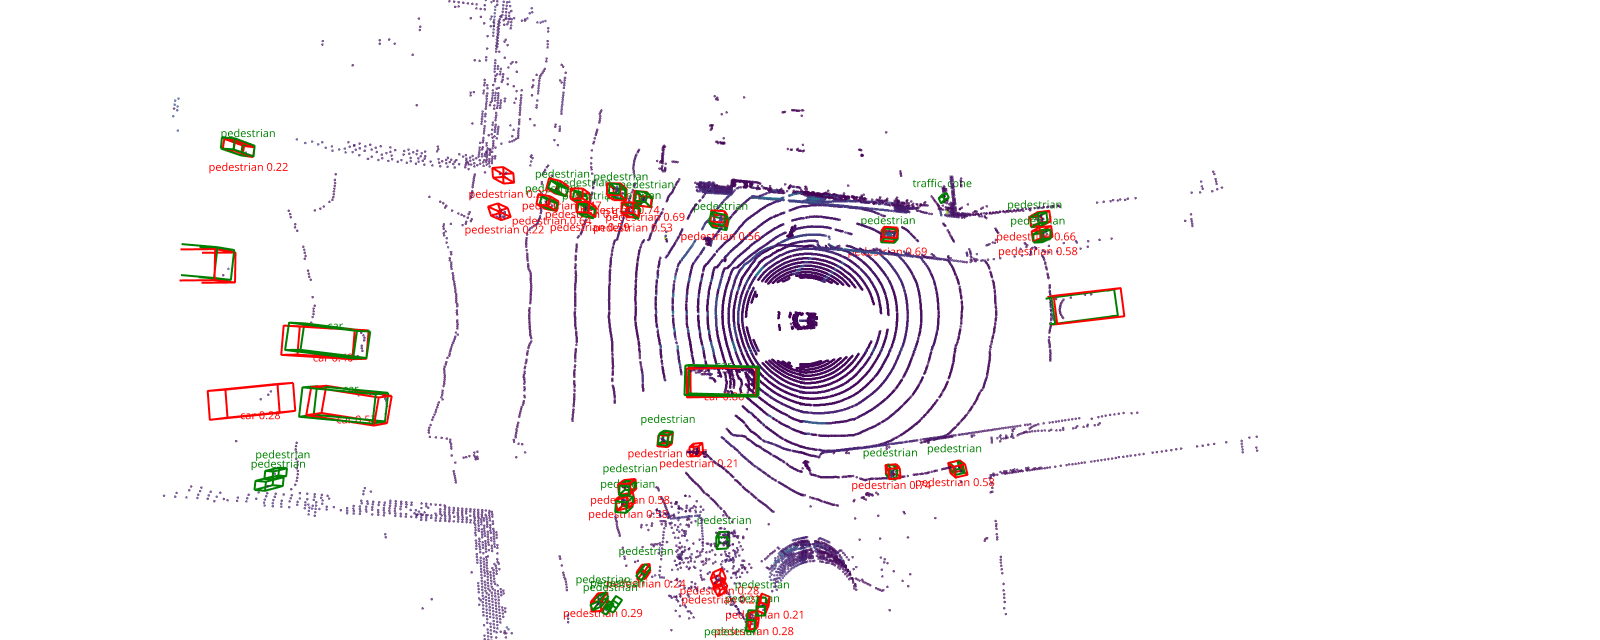
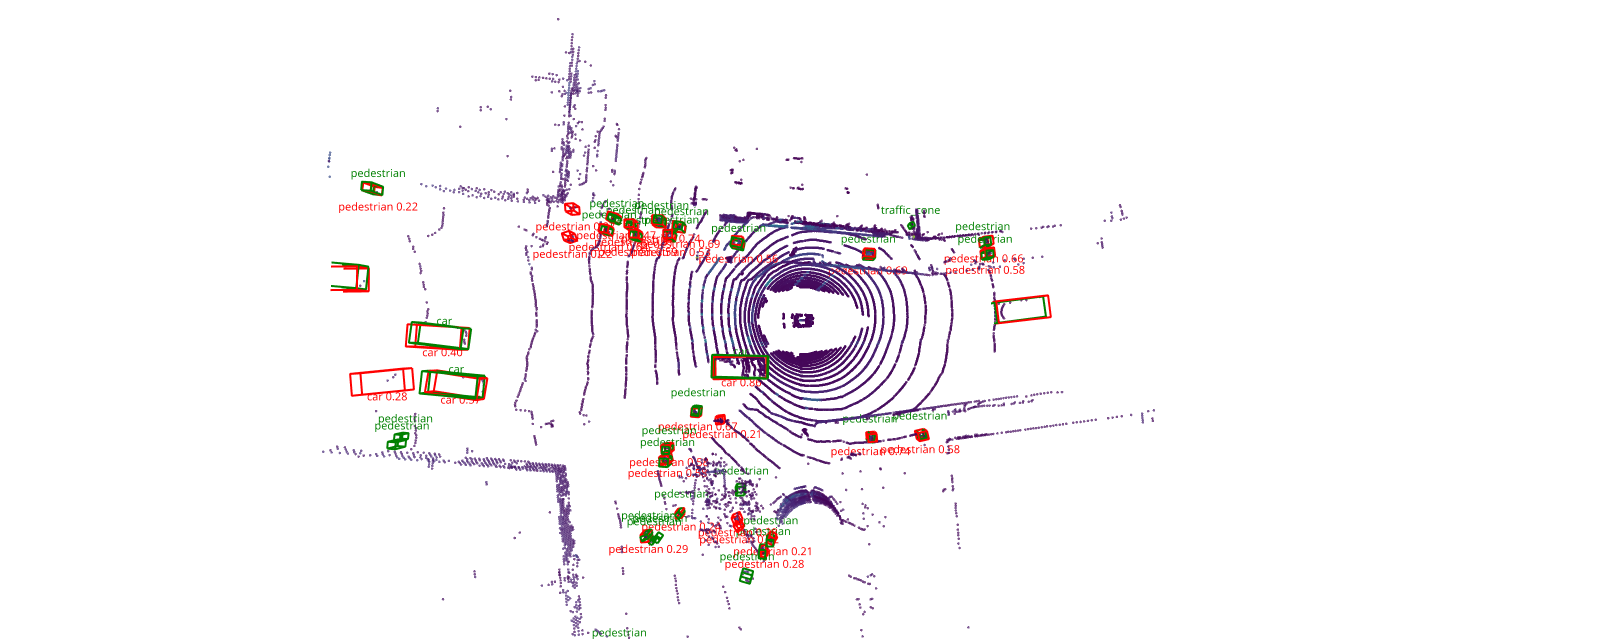
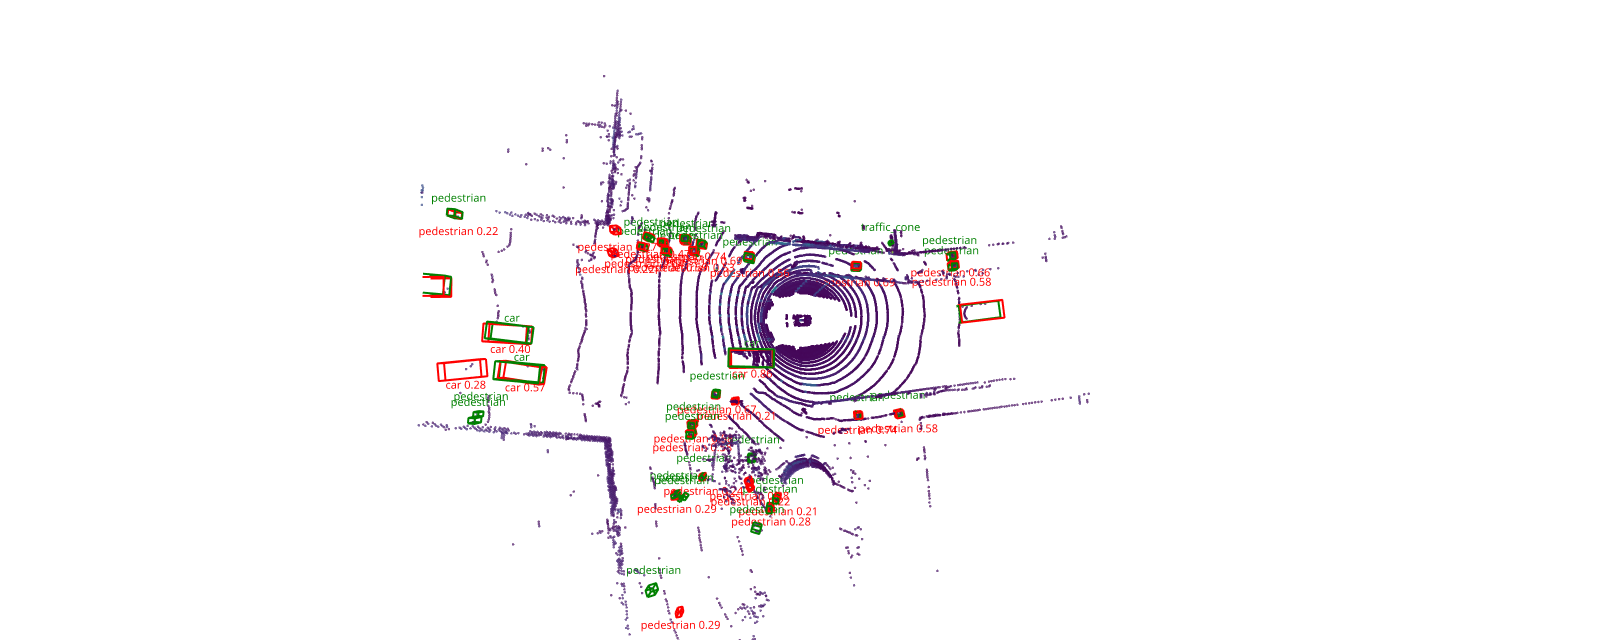
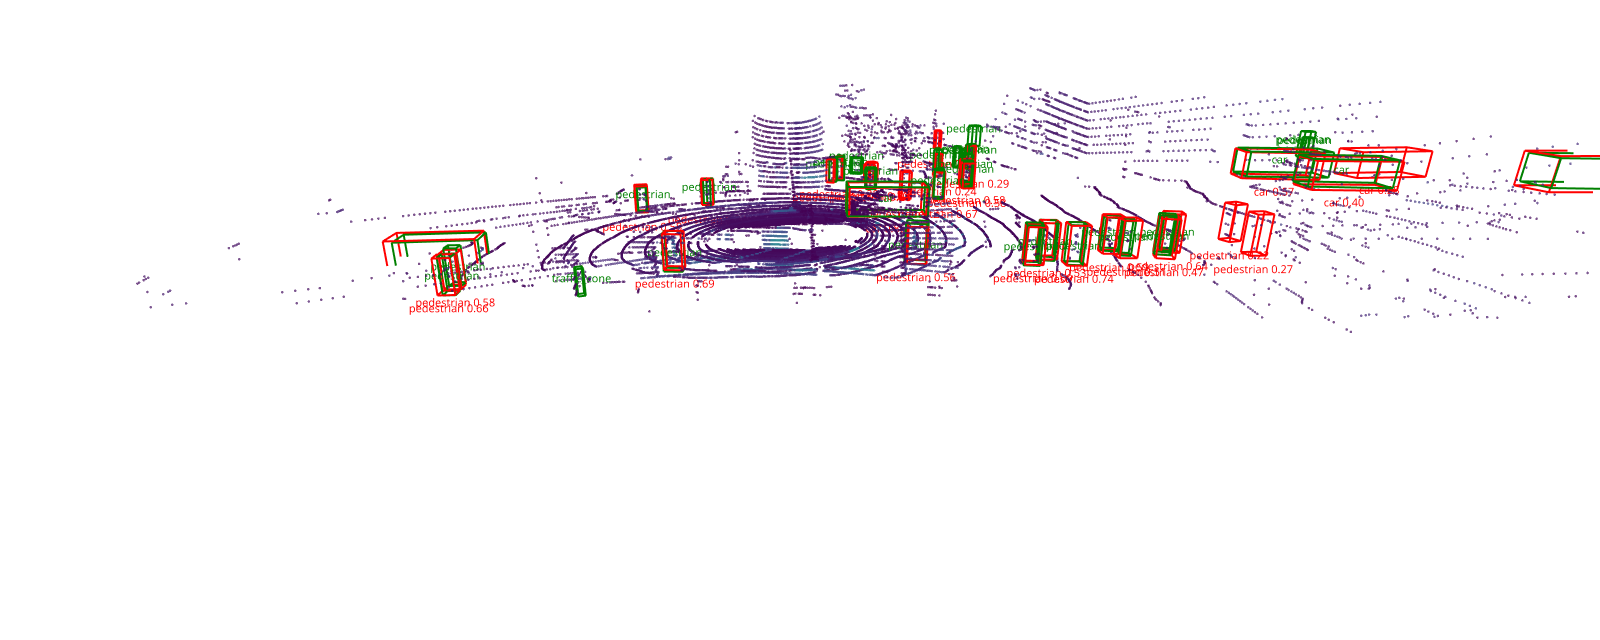
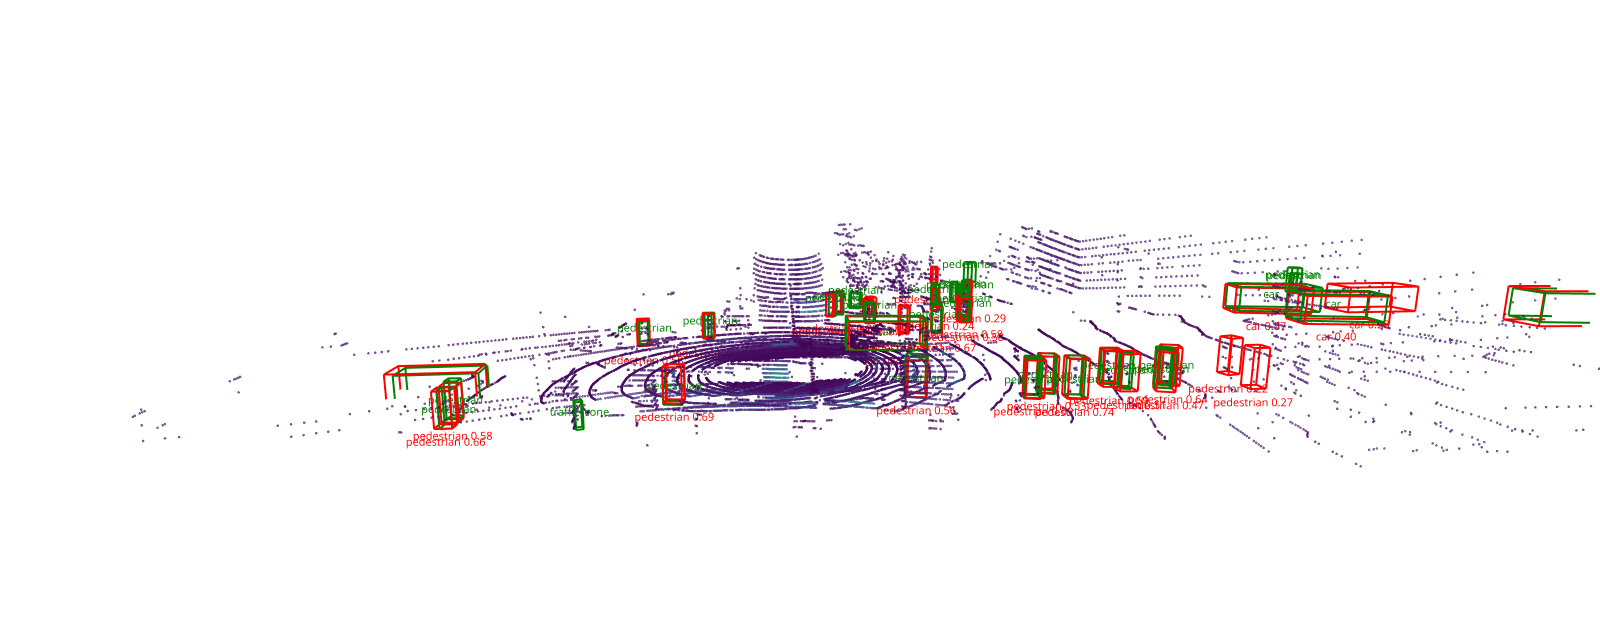
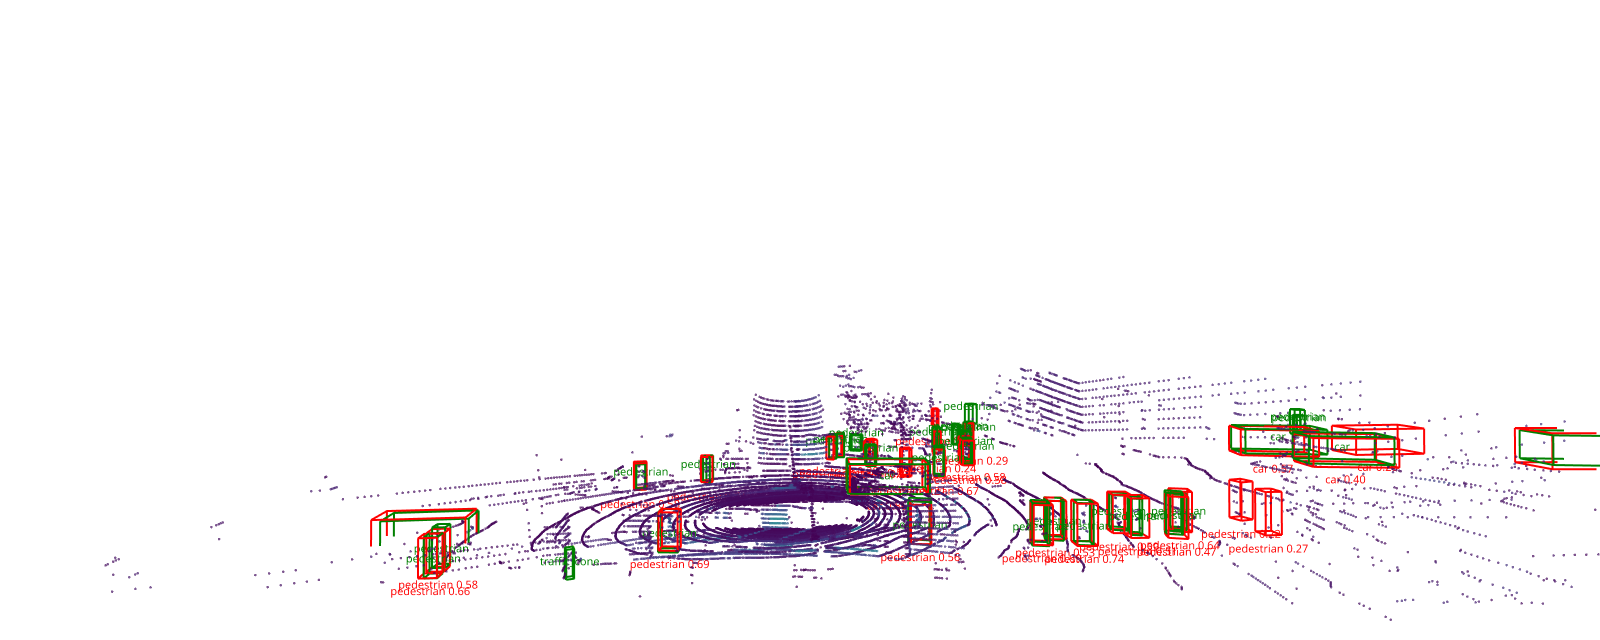
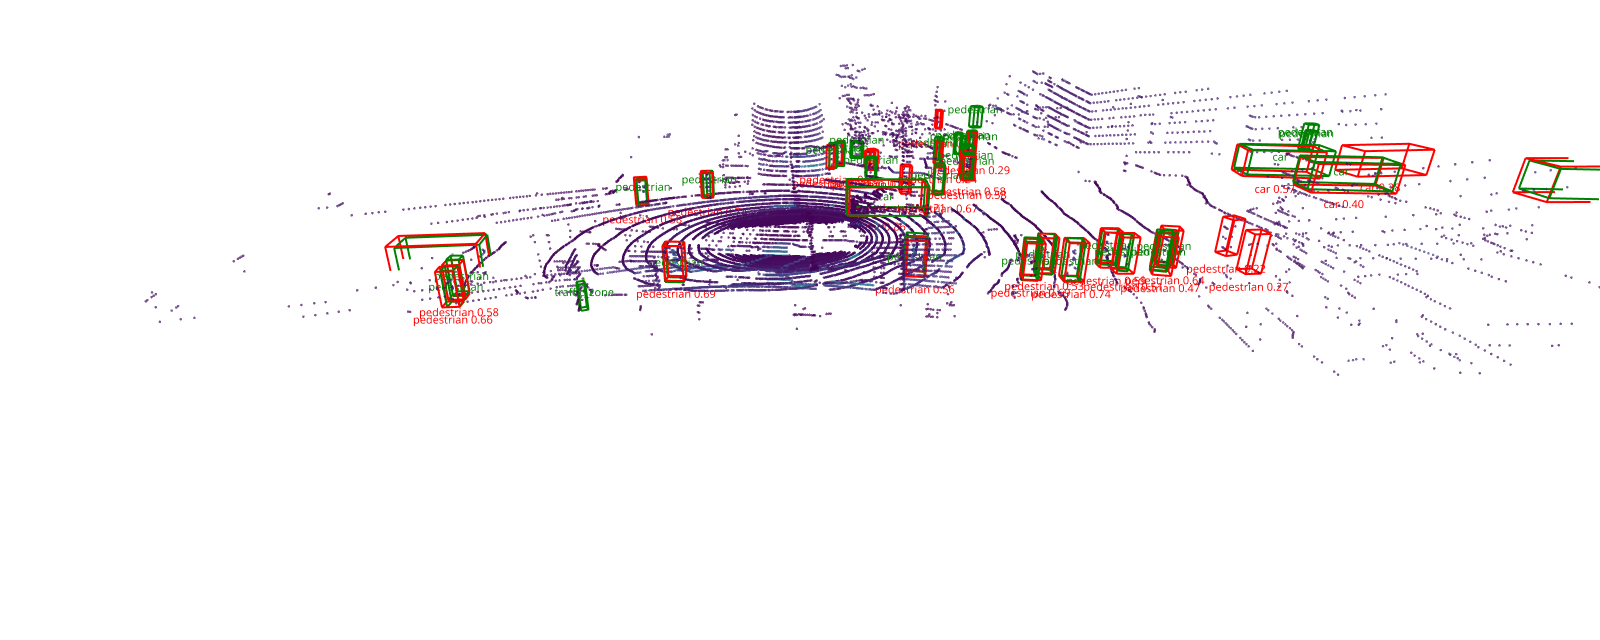
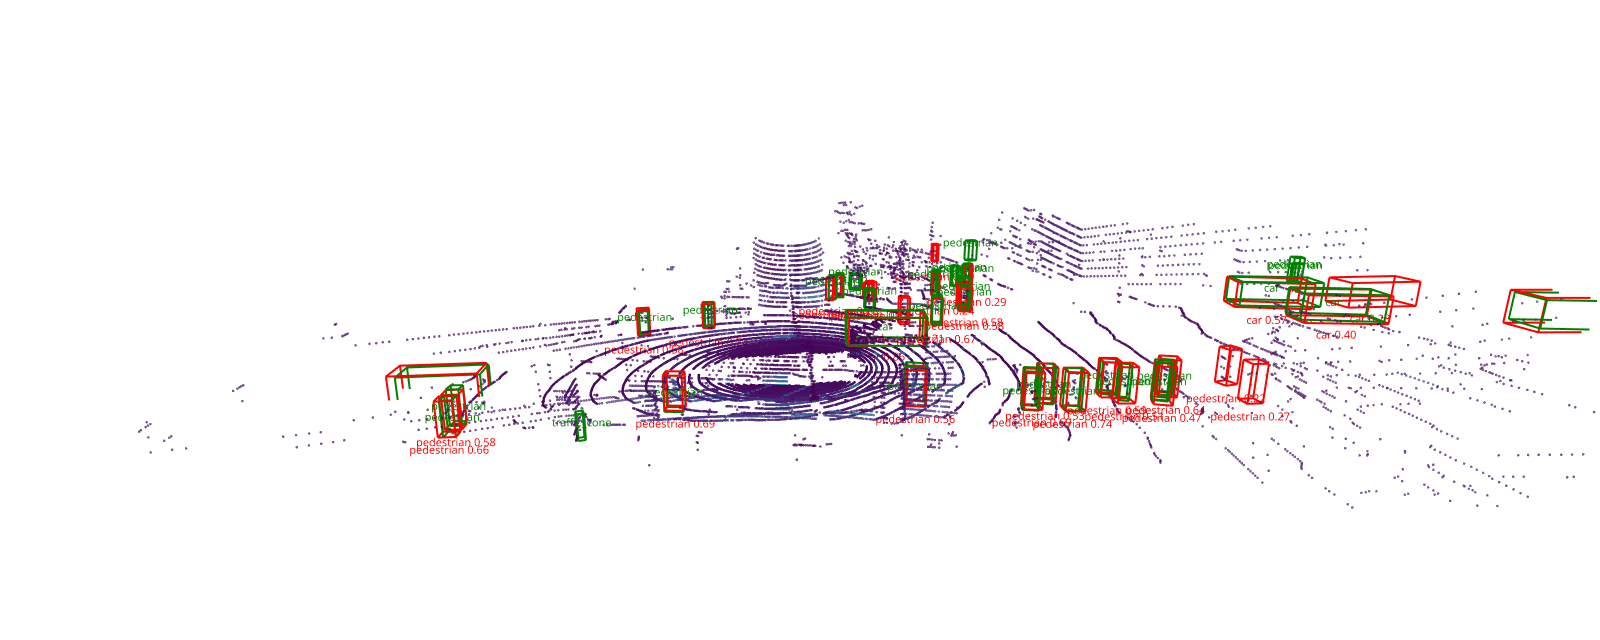
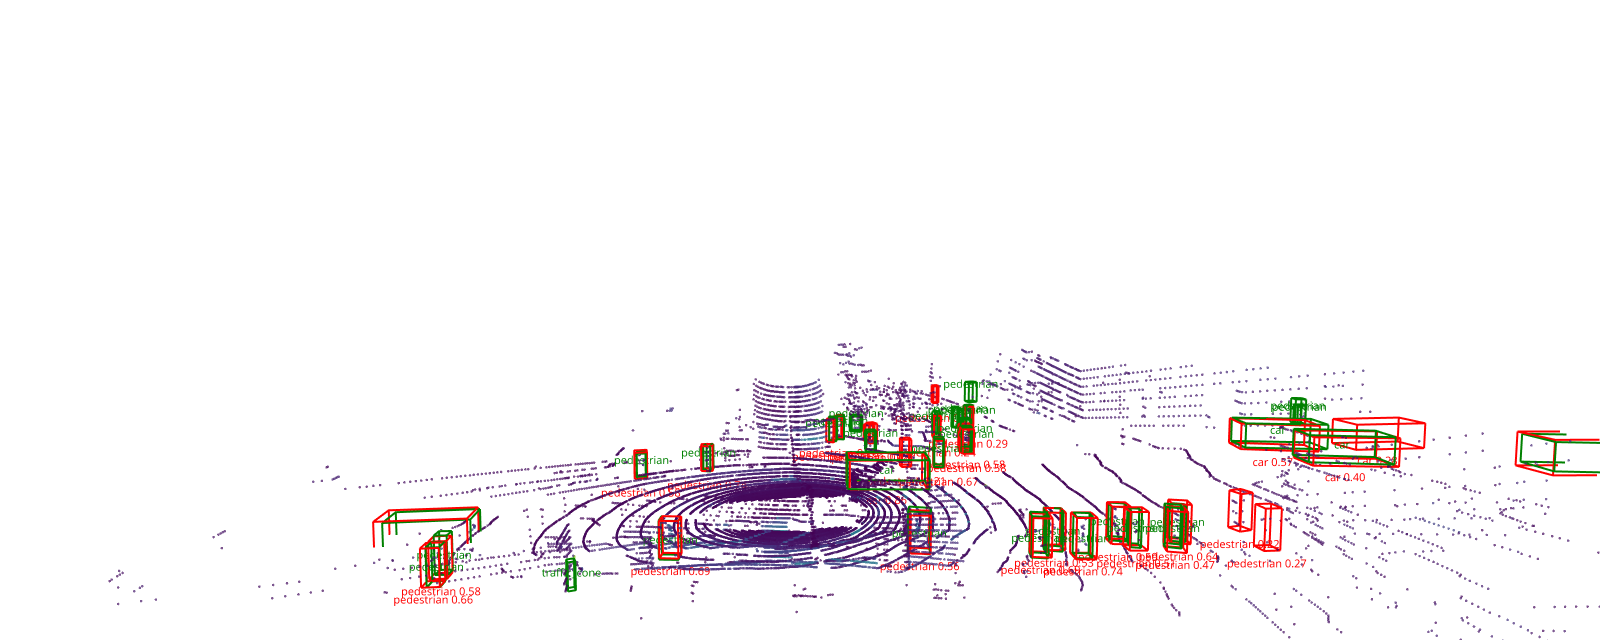
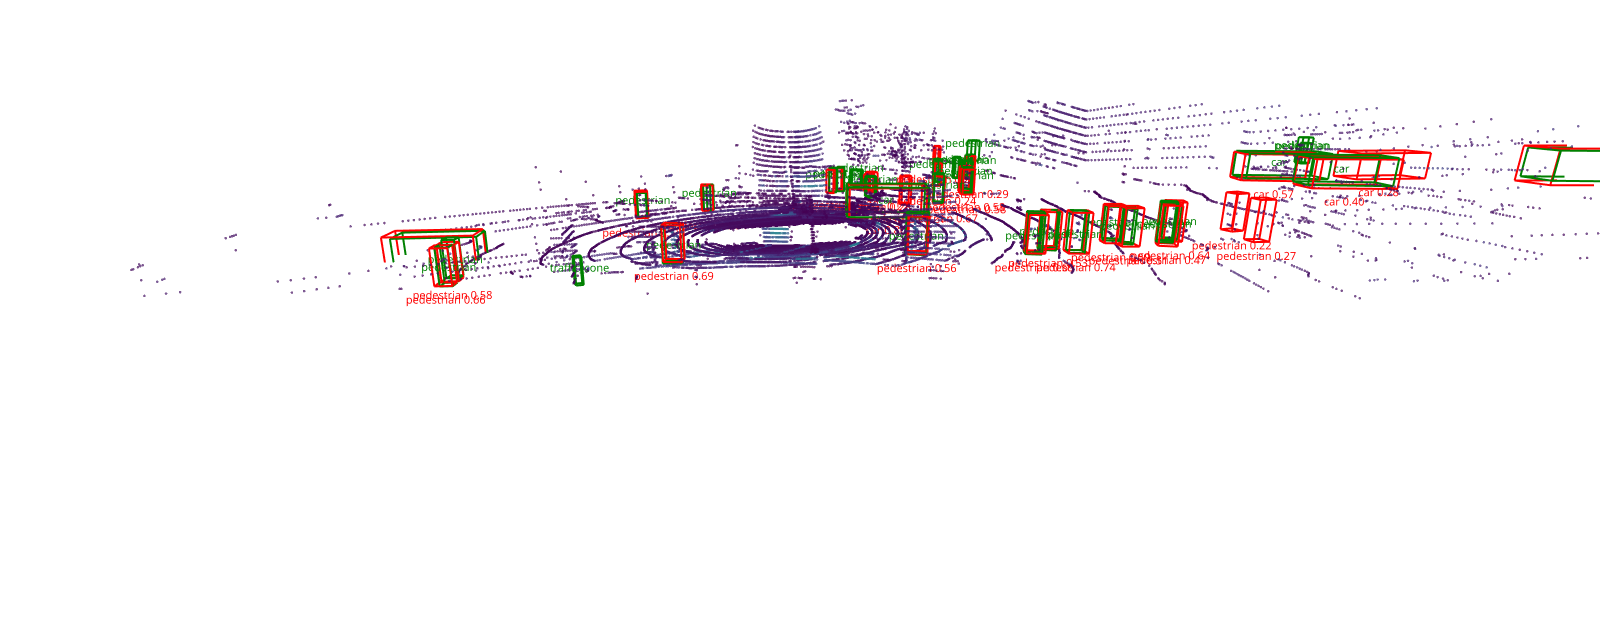
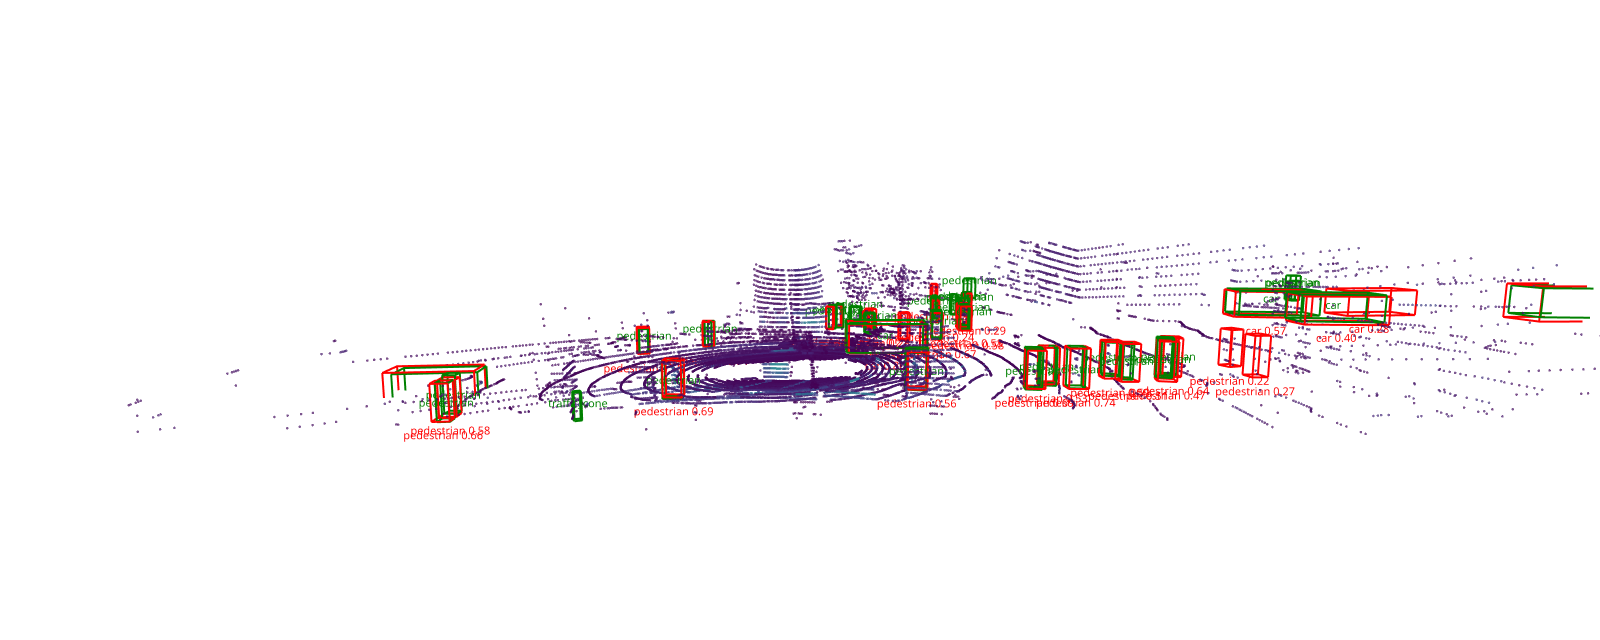
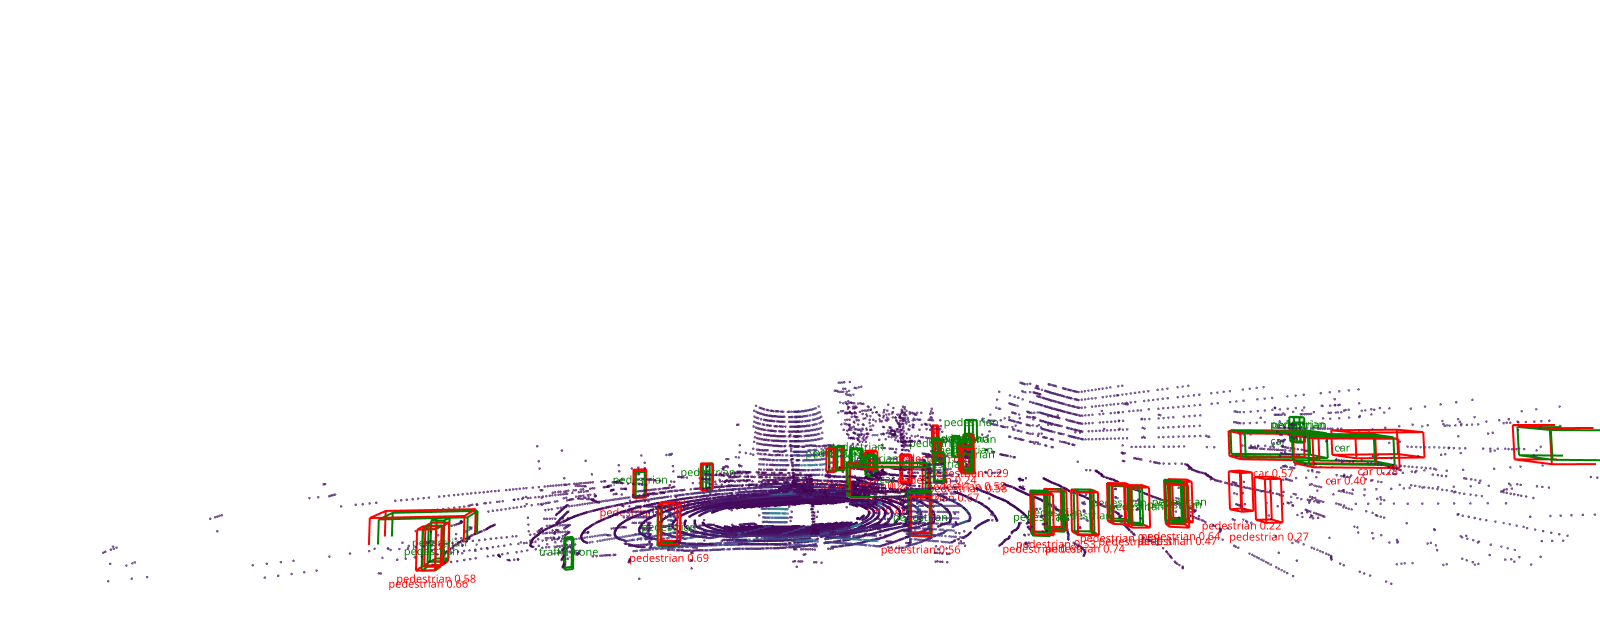
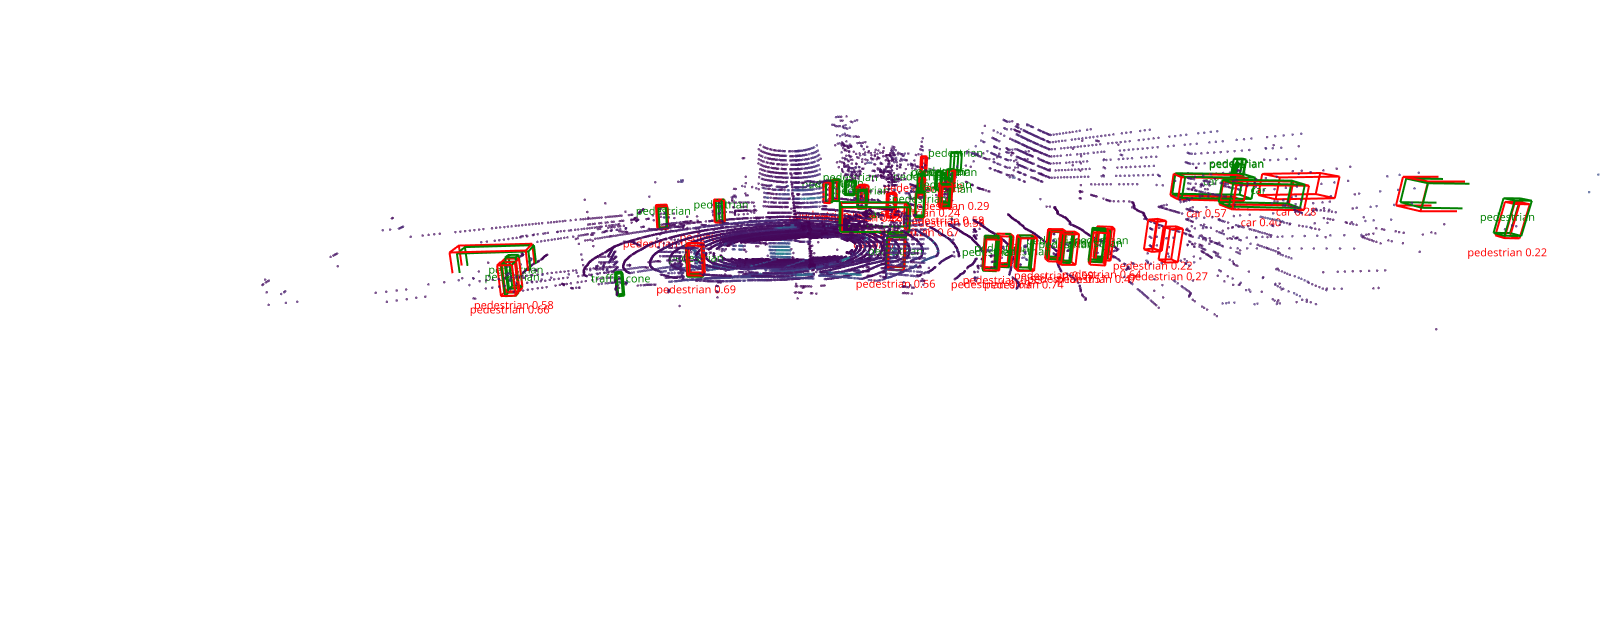
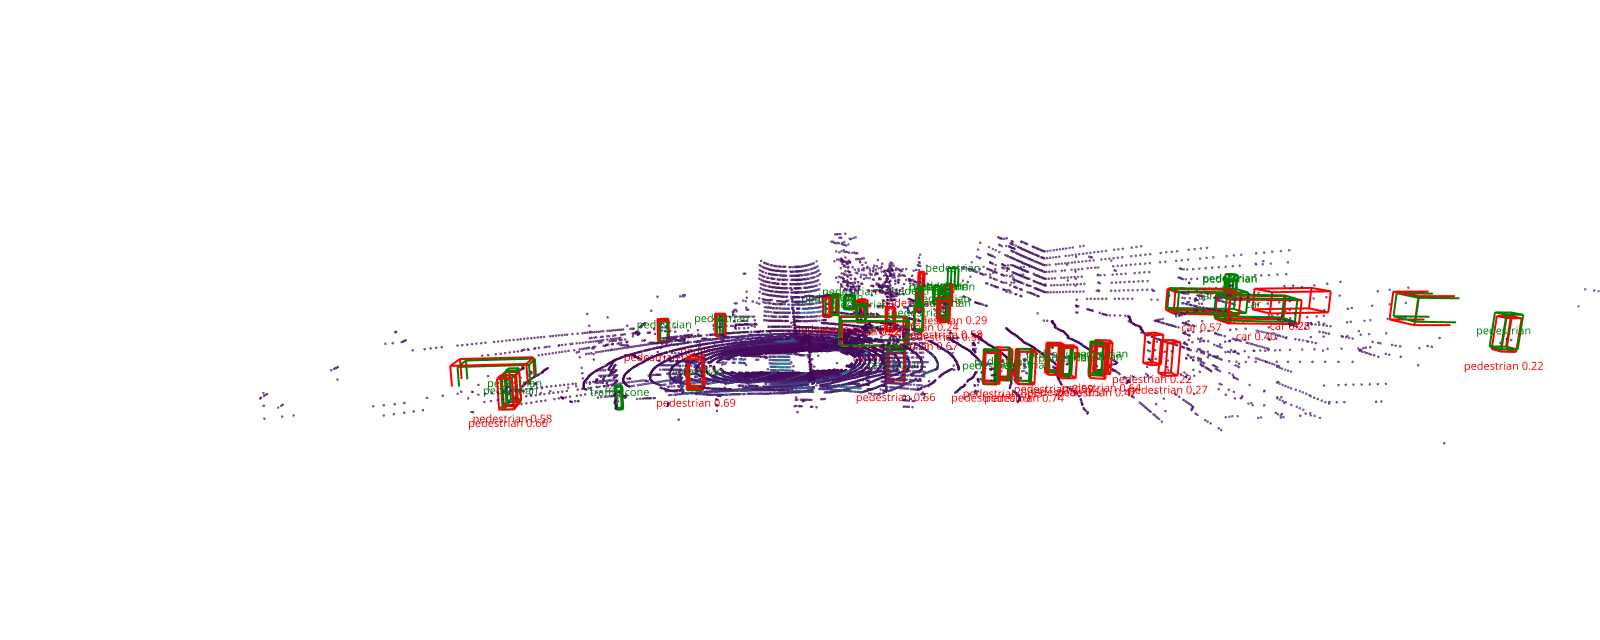
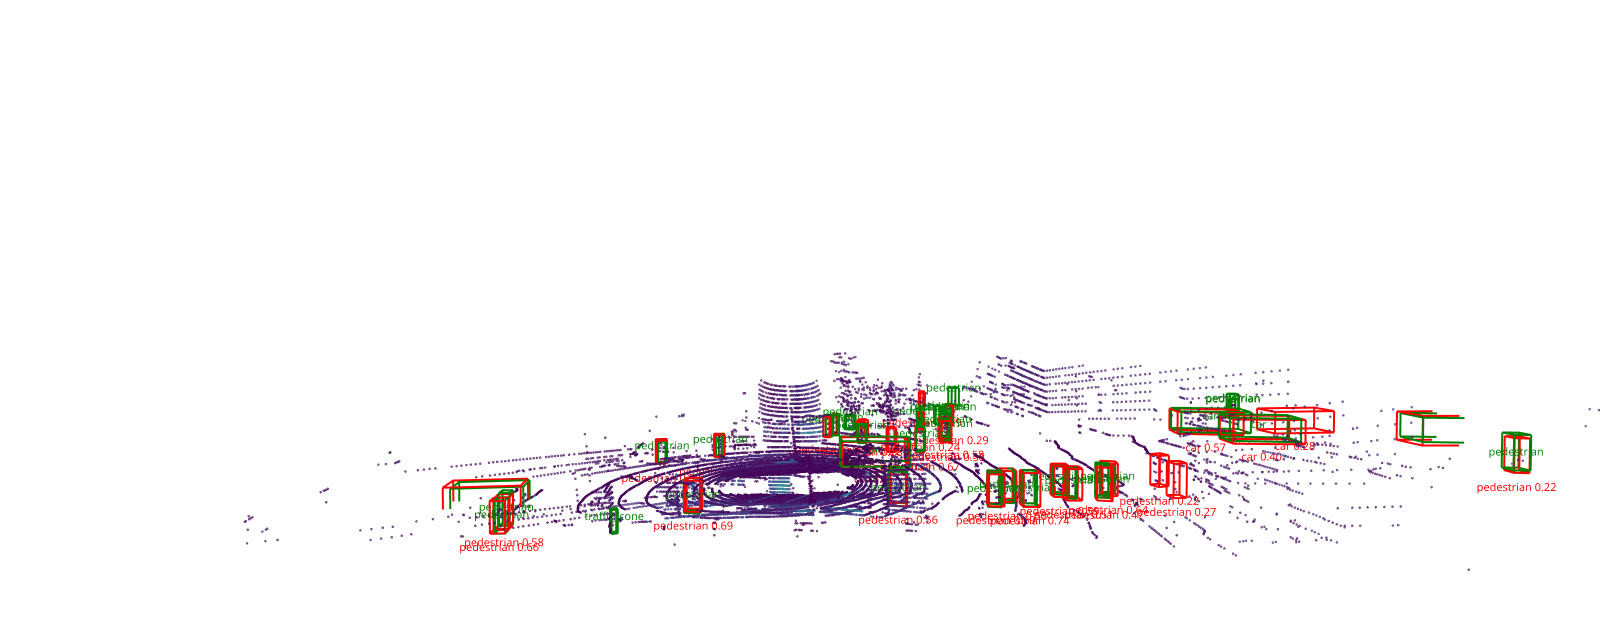
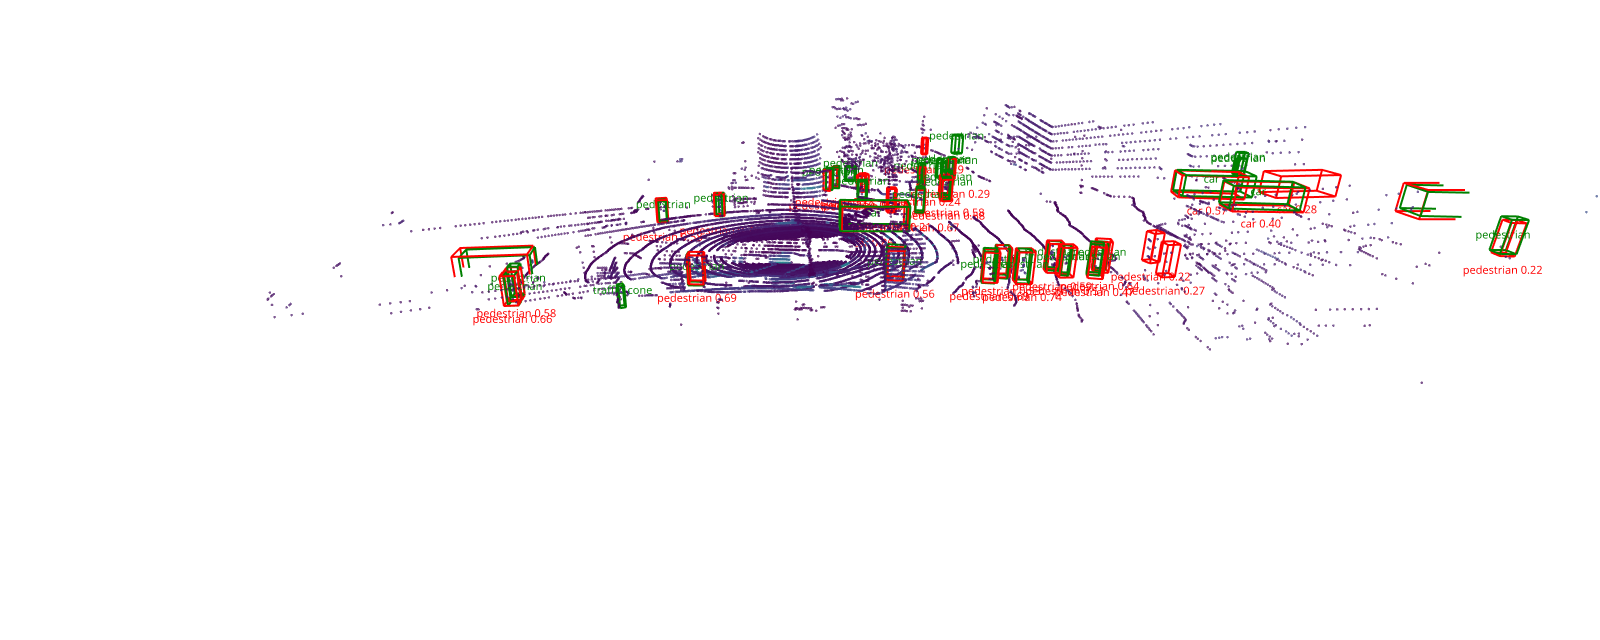
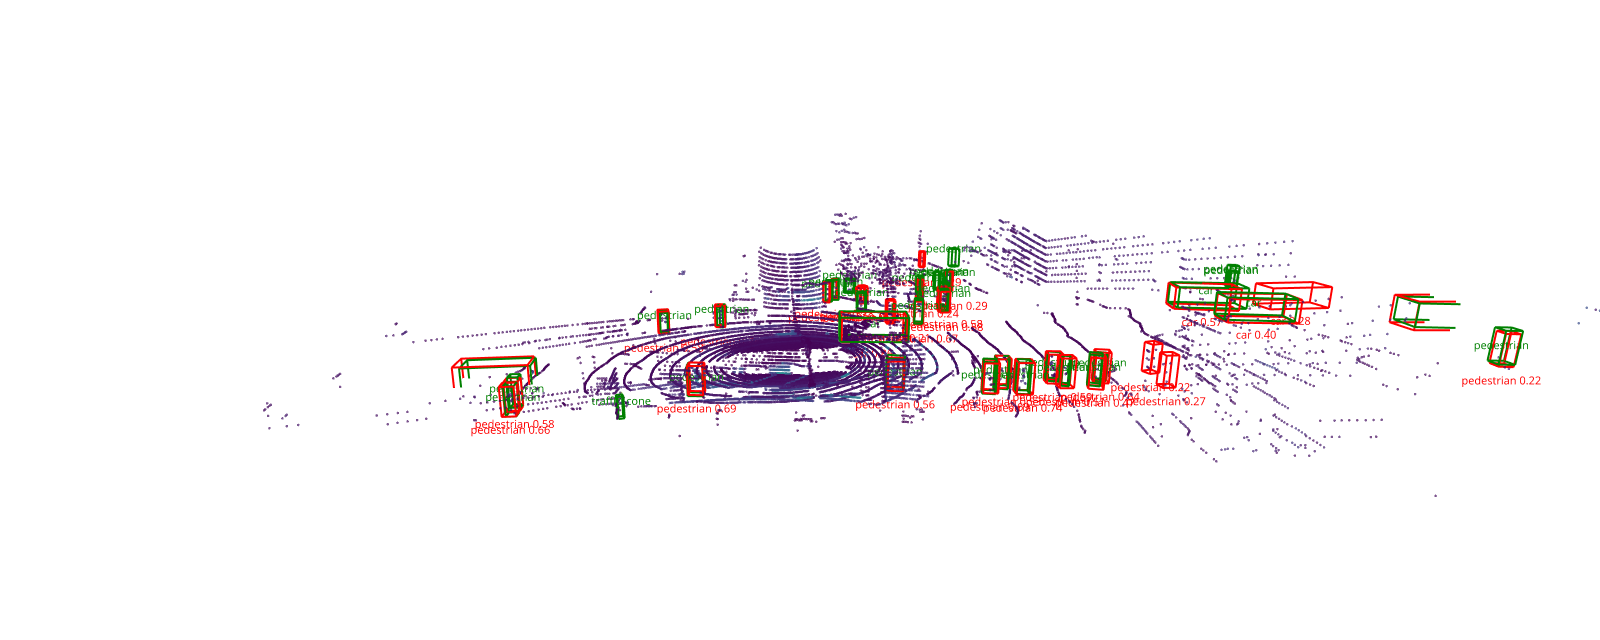
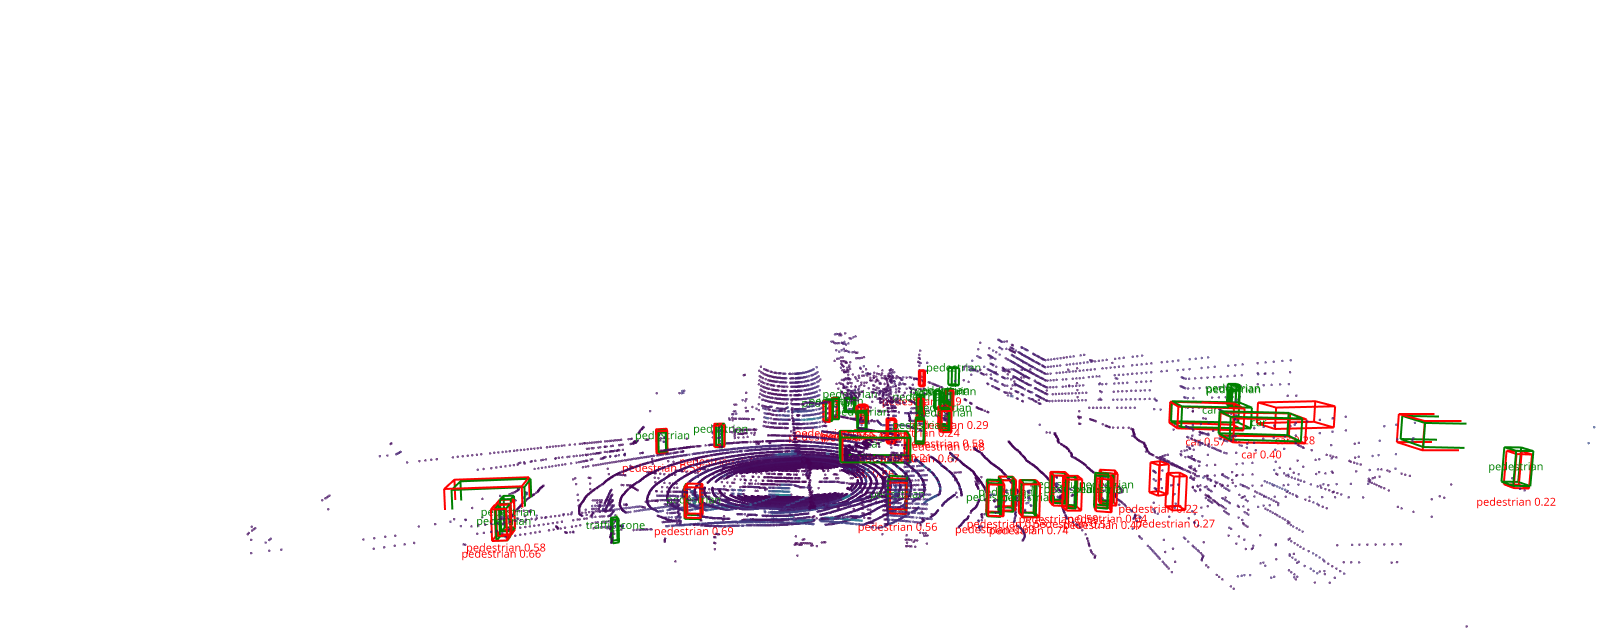
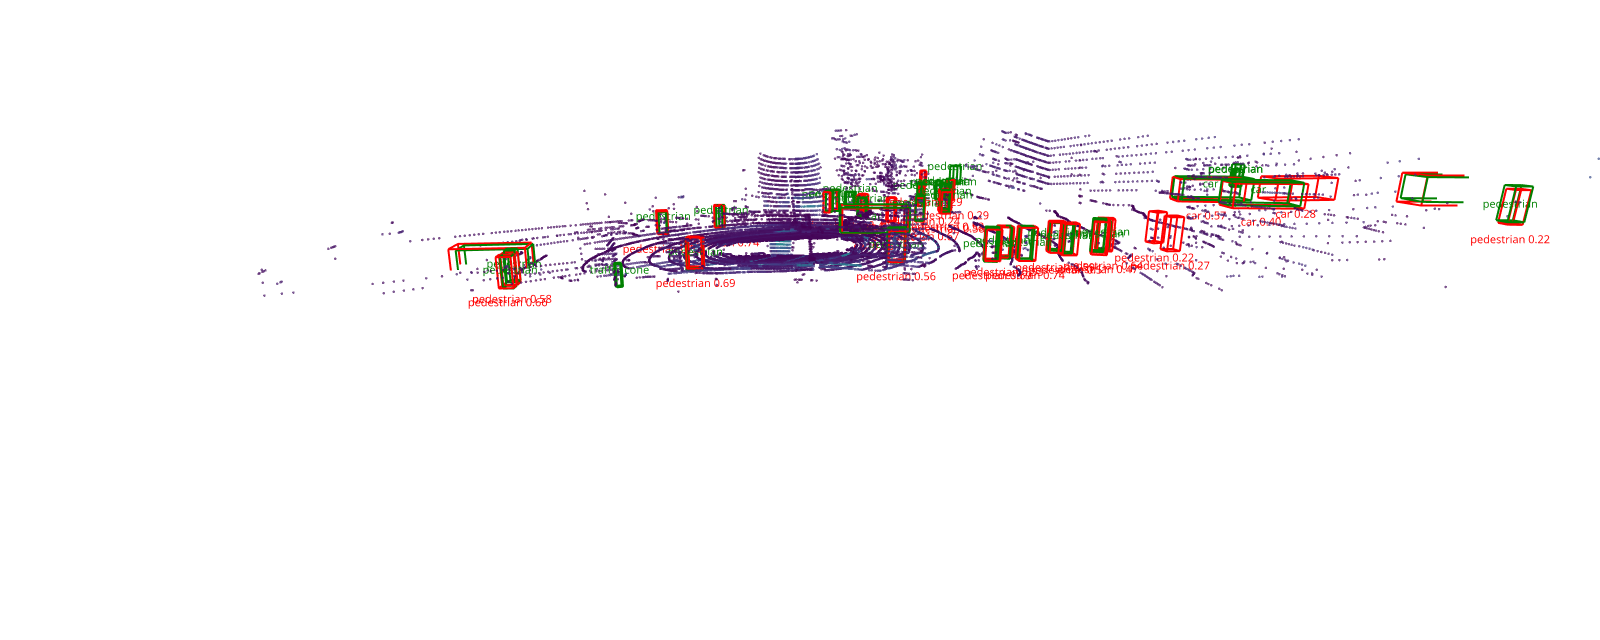
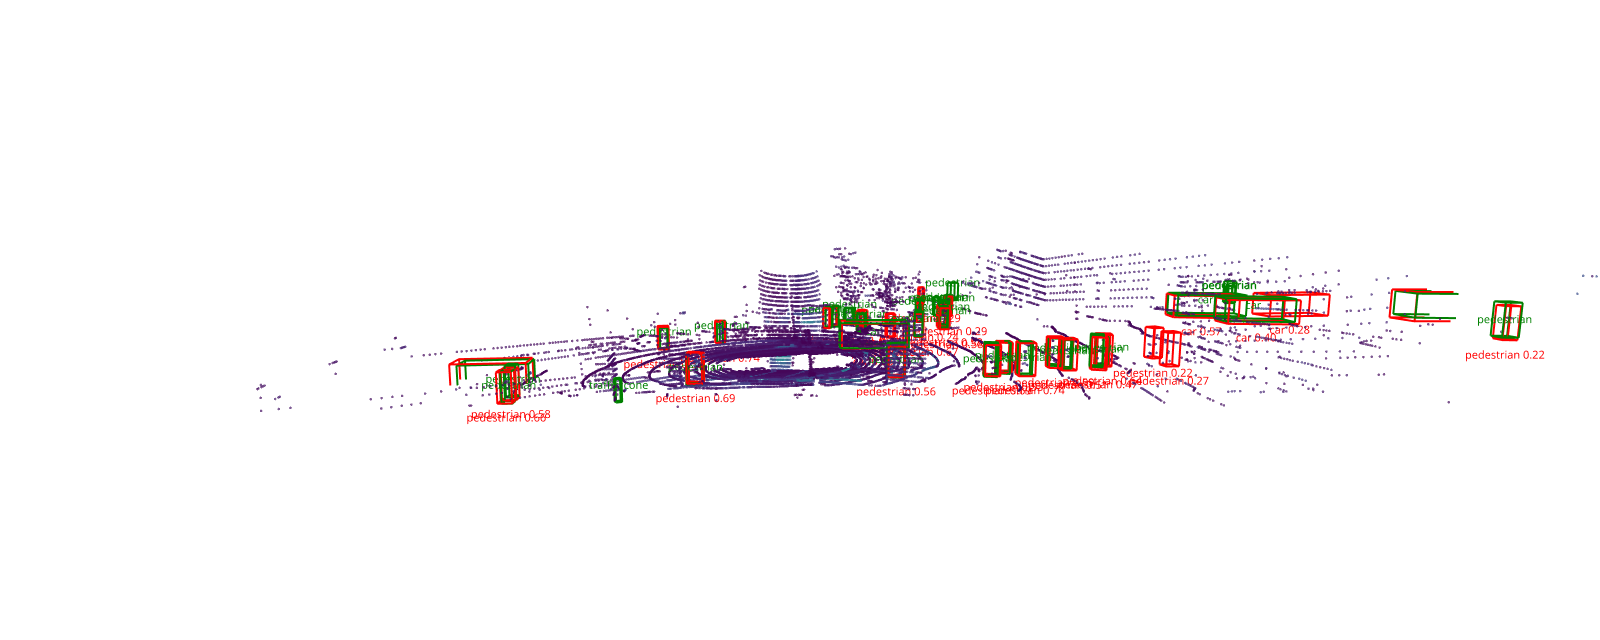
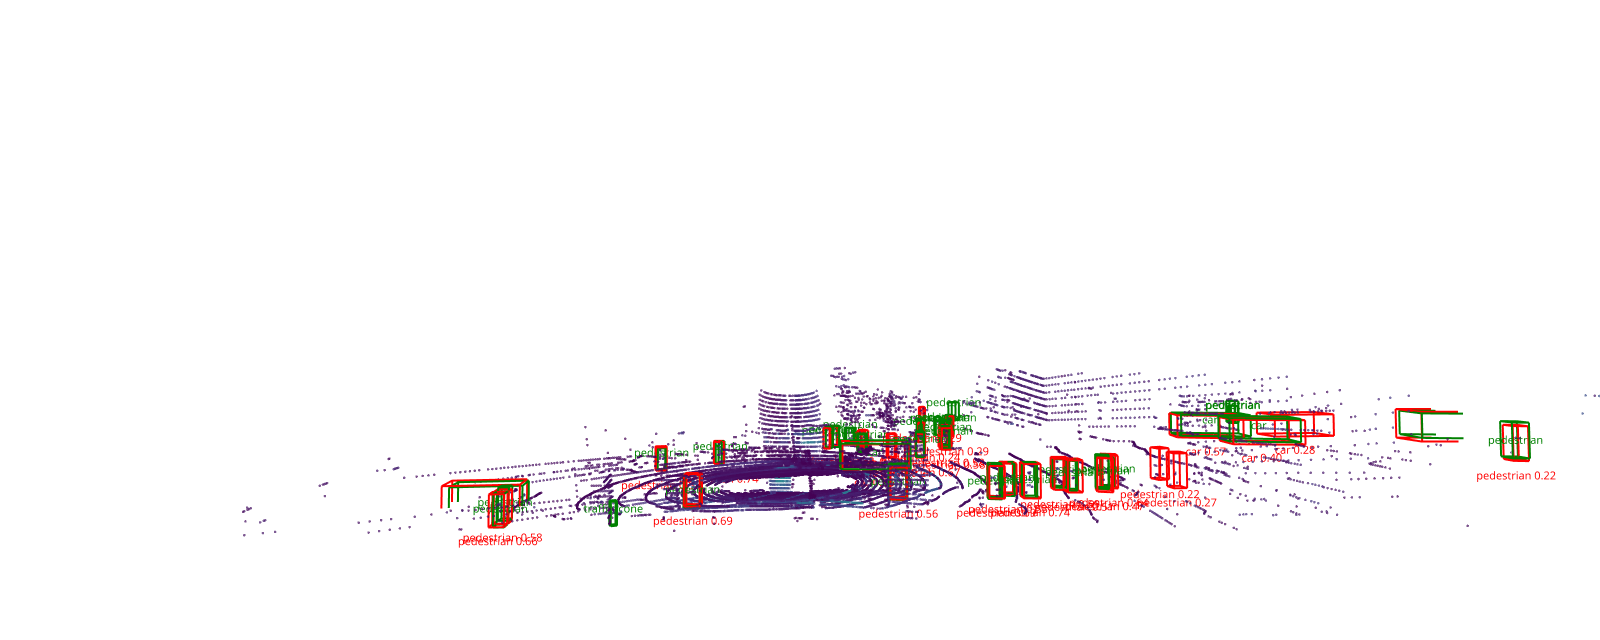
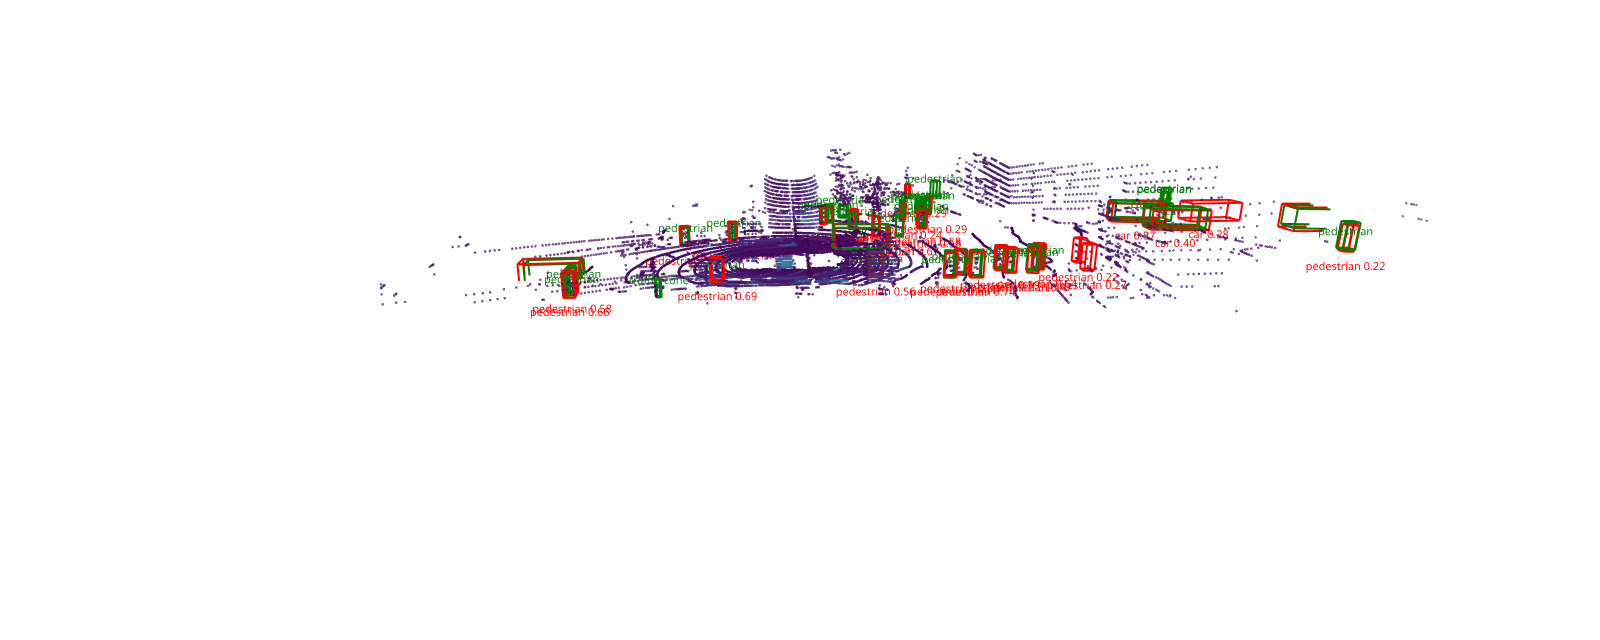
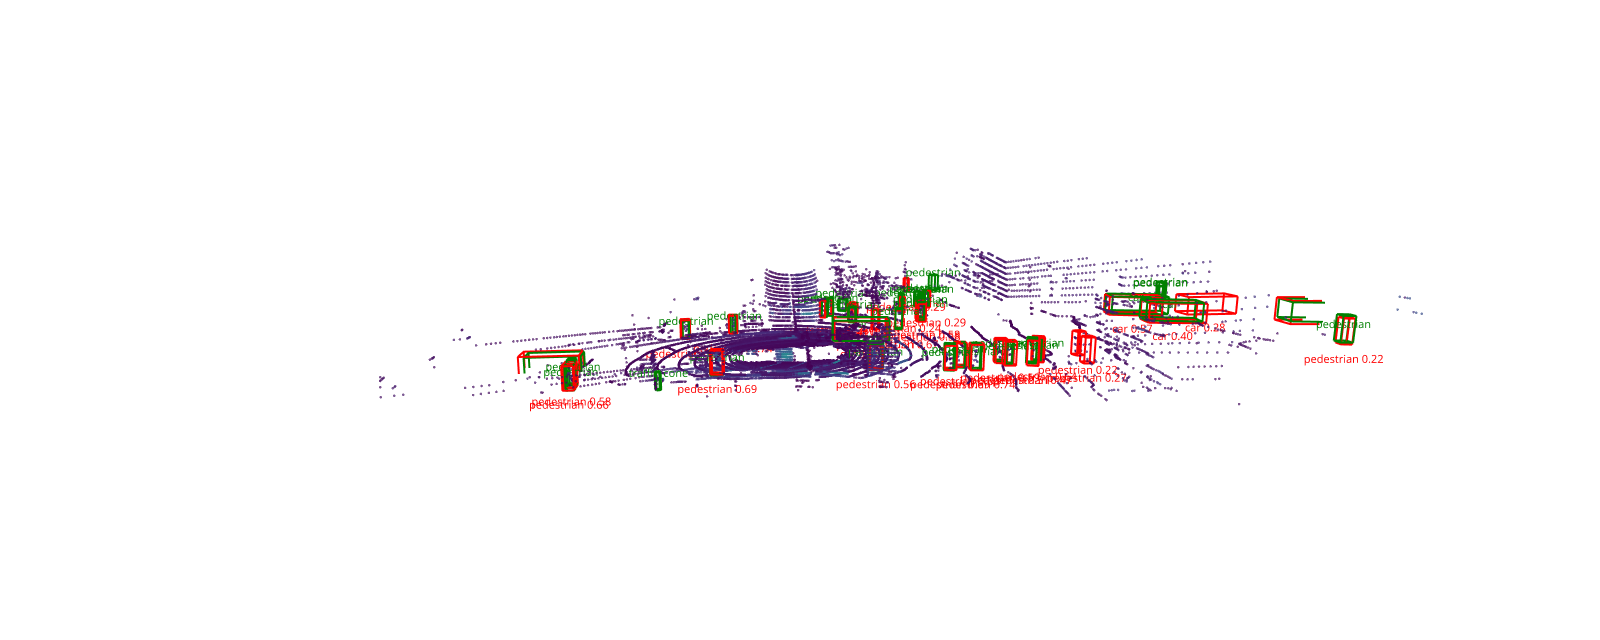
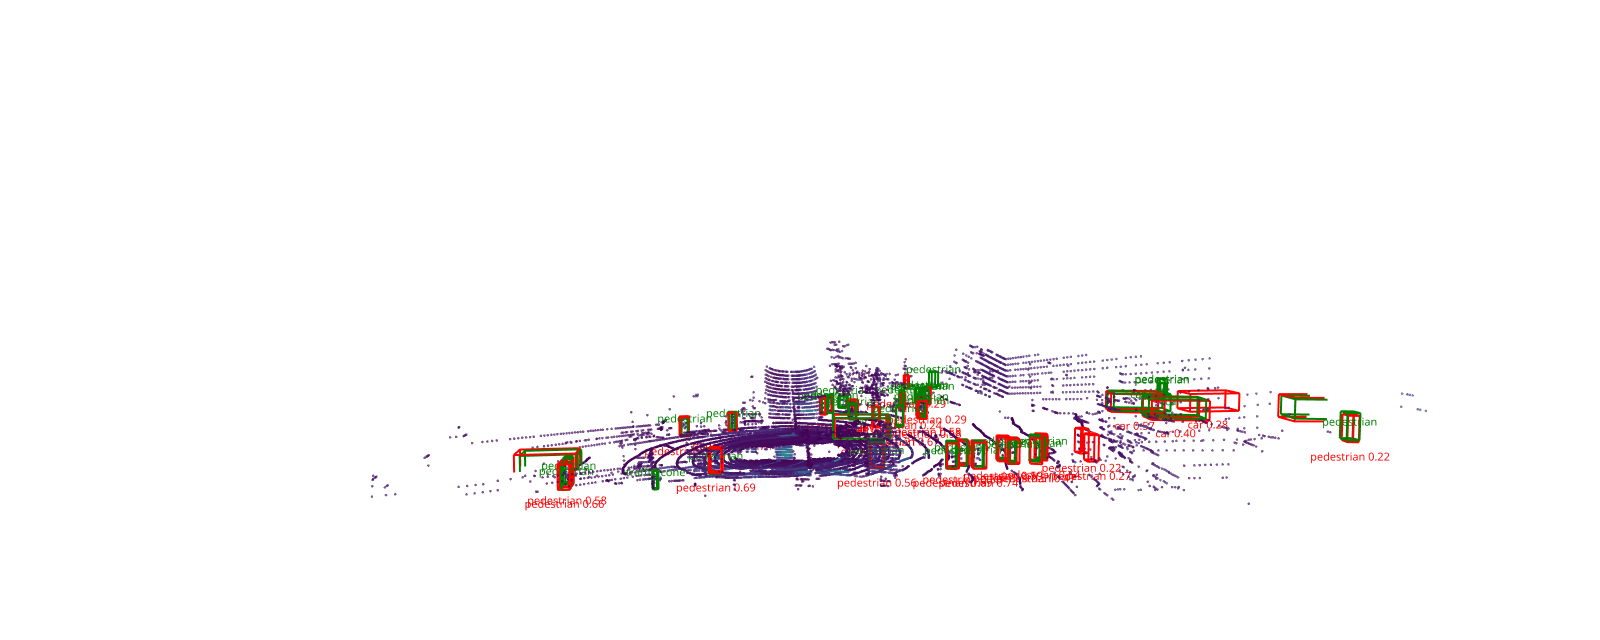
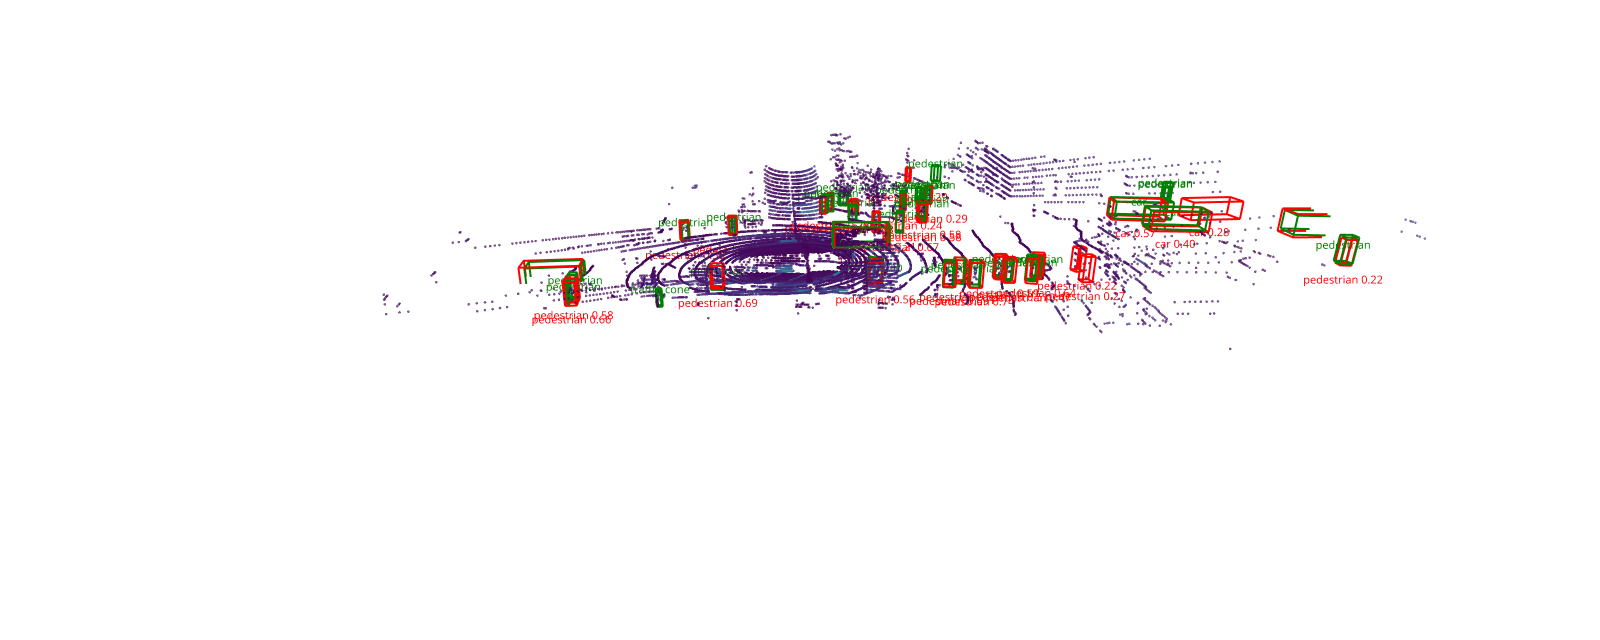
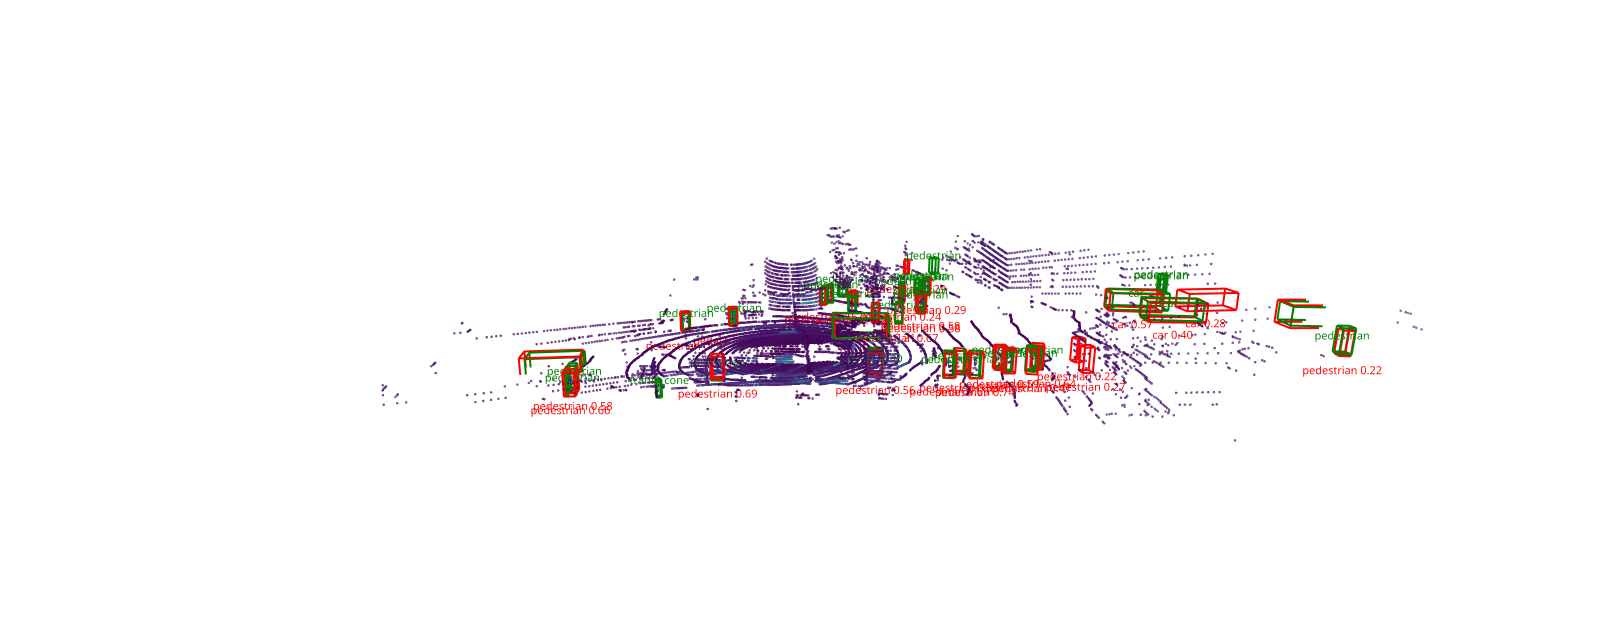
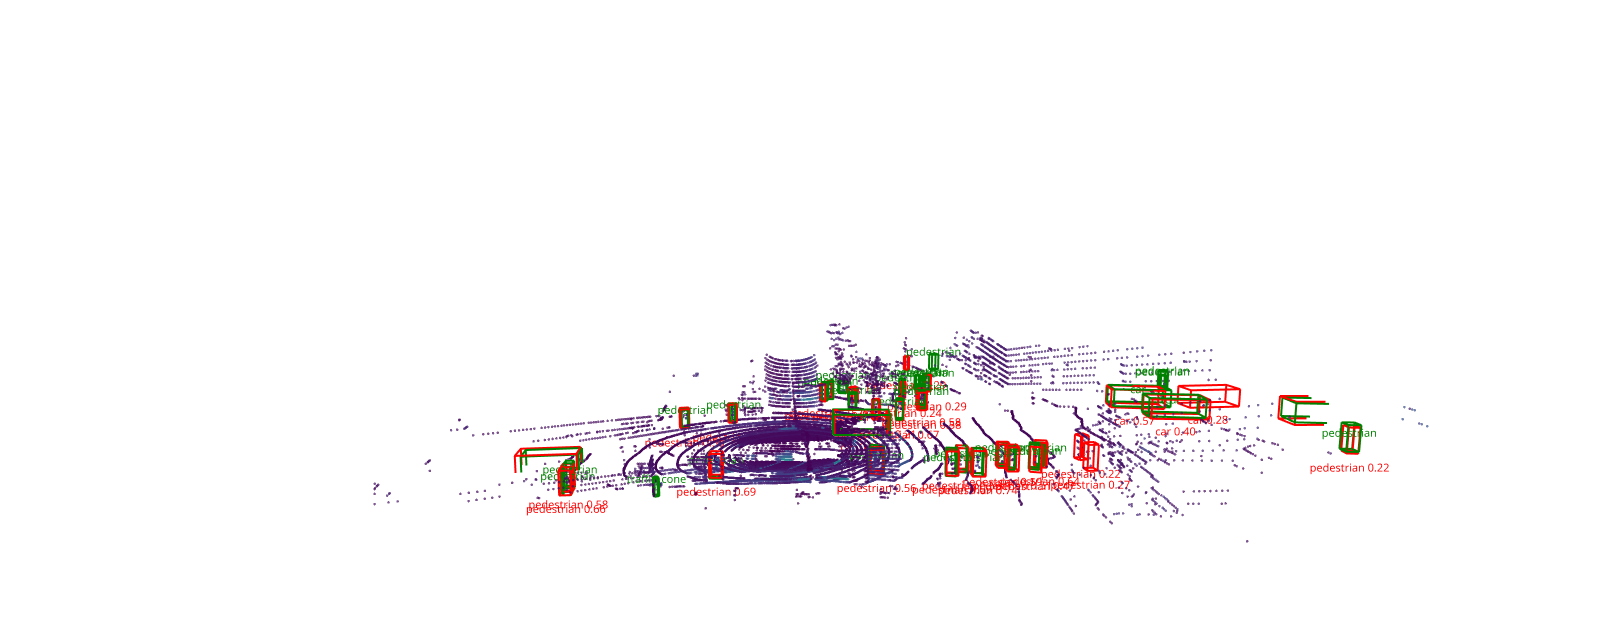
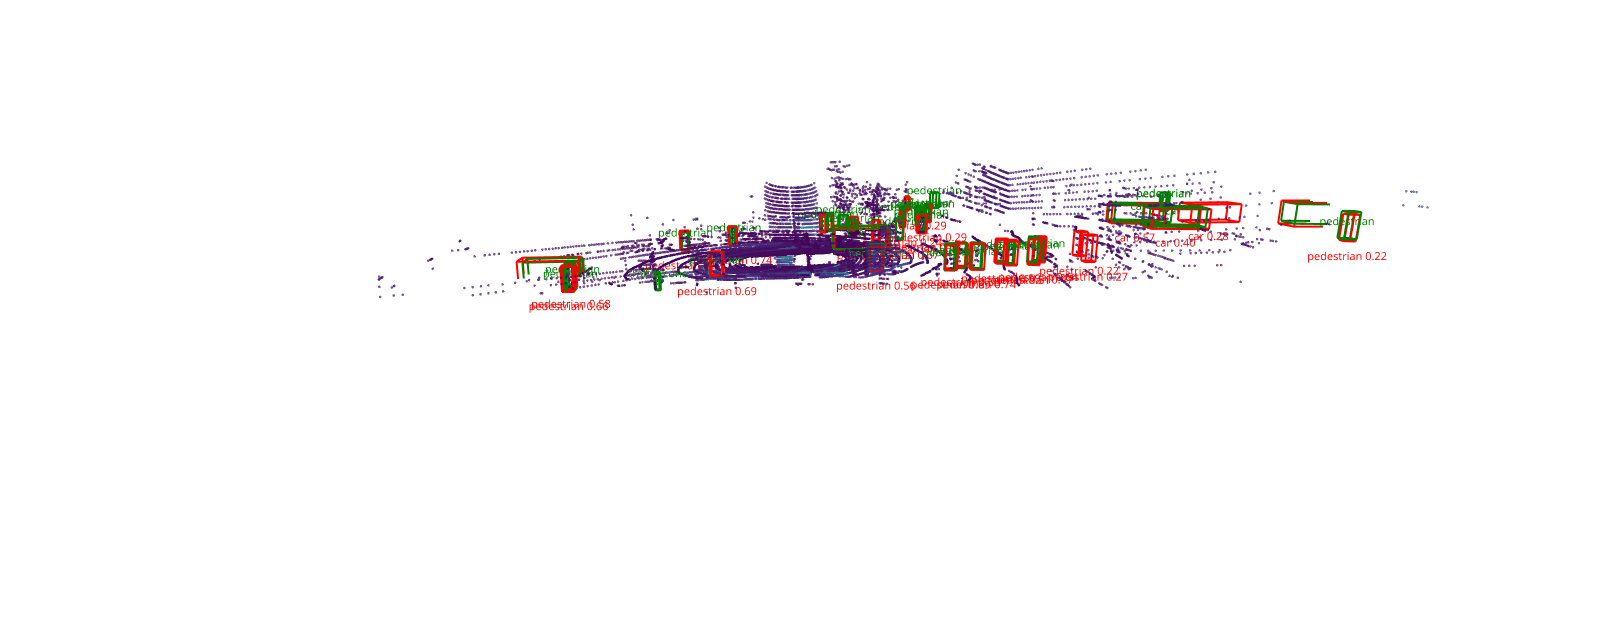
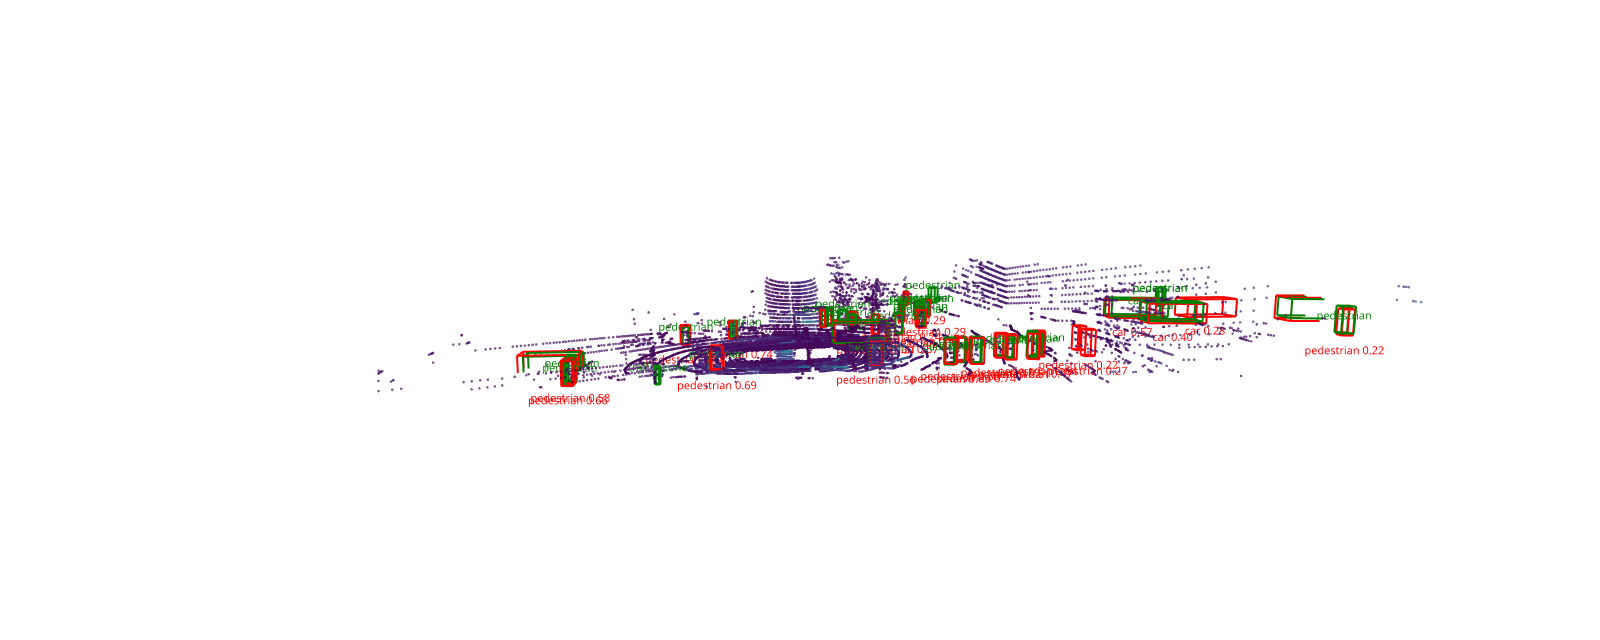
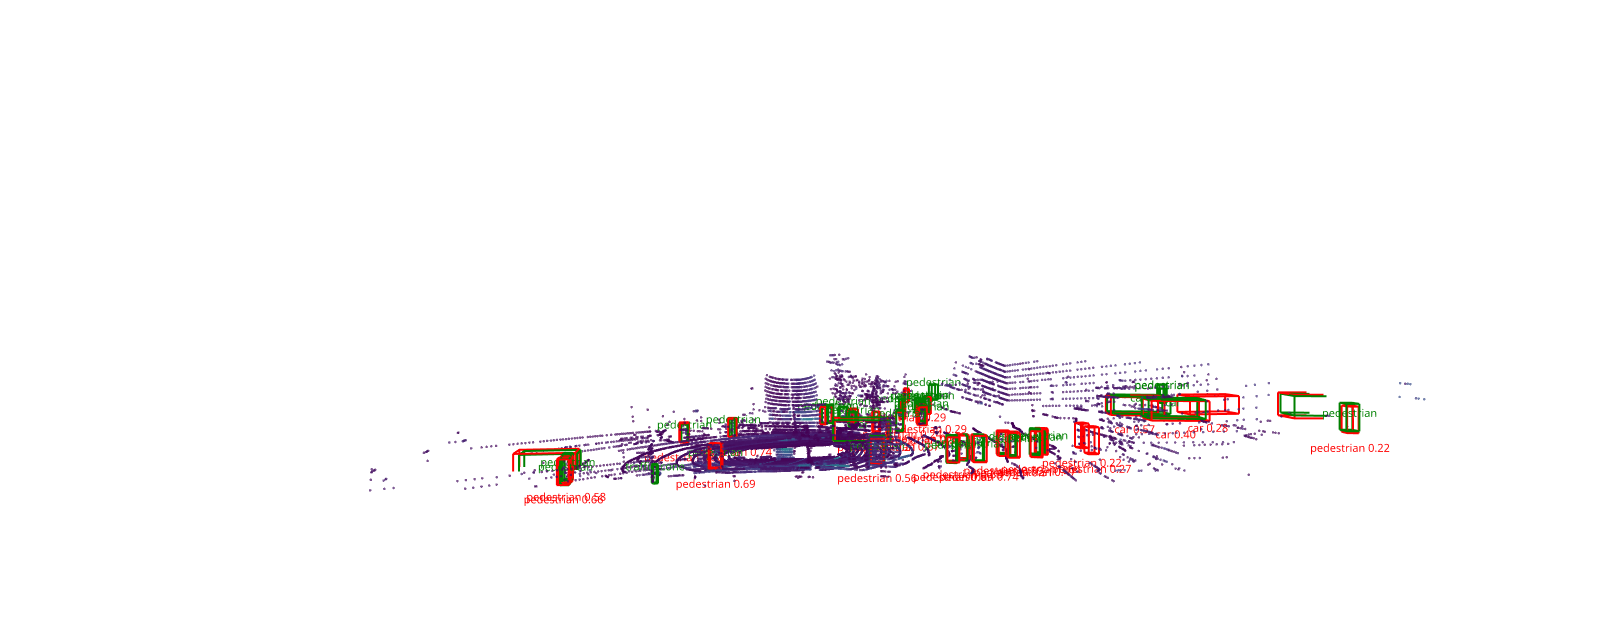

In [16]:
from itertools import product
from IPython.display import display, HTML

probe = Path("probe"); probe.mkdir(exist_ok=True)
for d, ph, cz in product([0.55, 0.65, 0.8], [7, 10, 14], [-0.1, 0.0, 0.1]):
    fig.update_layout(scene_camera=camera(0.0, np.deg2rad(ph), d, (0, 0, cz)))
    fig.write_image(probe / f"d{d}_p{ph}_c{cz}.png", scale=1)

for d in [0.65, 0.85, 1.05]:                    # top-down clips most easily
    fig.update_layout(scene_camera=camera(np.pi, np.deg2rad(88), d))
    fig.write_image(probe / f"bev_d{d}.png", scale=1)

cells = []
for p in sorted(probe.glob("*.png")):
    b64 = base64.b64encode(p.read_bytes()).decode()
    cells.append(f'<div style="display:inline-block;margin:4px;text-align:center">'
                 f'<img src="data:image/png;base64,{b64}" width="380"><br>'
                 f'<code style="font-size:11px">{p.stem}</code></div>')
display(HTML("".join(cells)))

In [17]:
for tr in fig.data:
    if tr.type != "scatter3d":
        continue
    print(f"{tr.name!r:32} mode={tr.mode!r:18} "
          f"marker.size={getattr(tr.marker, 'size', None)} "
          f"line.width={getattr(tr.line, 'width', None)} "
          f"textfont={getattr(tr.textfont, 'size', None)}")

'LiDAR Points'                   mode='markers'          marker.size=1.5 line.width=None textfont=None
'GT Bounding Boxes'              mode='lines'            marker.size=None line.width=4 textfont=None
None                             mode='text'             marker.size=None line.width=None textfont=11
'Predicted Bounding Boxes'       mode='lines'            marker.size=None line.width=4 textfont=None
None                             mode='text'             marker.size=None line.width=None textfont=11


In [24]:
for tr in fig.data:
    if tr.type != "scatter3d":
        continue
    mode = tr.mode or ""
    if "markers" in mode:
        tr.marker.size = 0.7          # LiDAR points
        tr.marker.opacity = 0.85
    if "lines" in mode:
        tr.line.width = 1             # box wireframes
    if "text" in mode:
        tr.textfont.size = 6          # the class/score labels

rendered (4800, 1920)


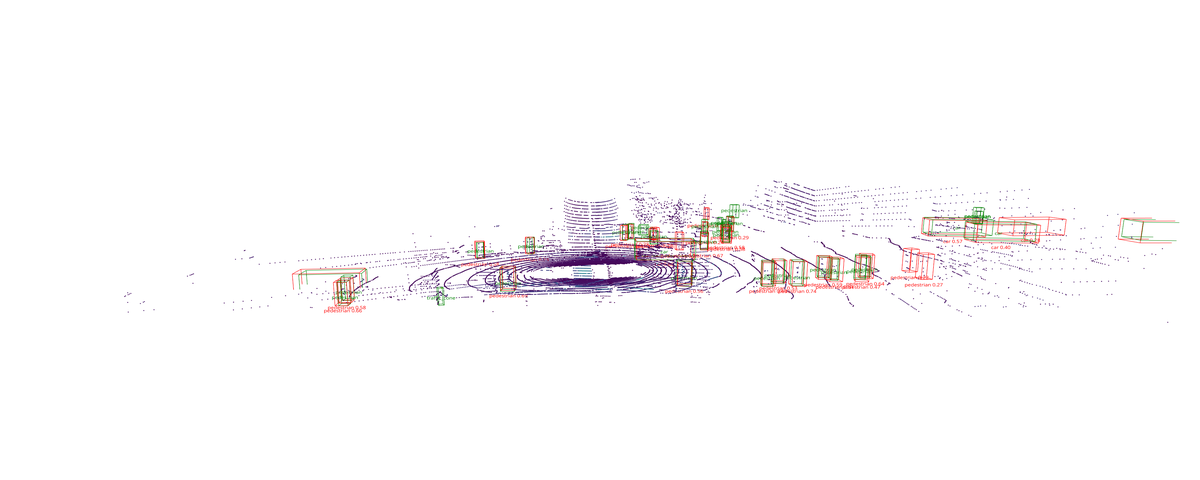

In [25]:
from PIL import Image
from IPython.display import display

fig.update_layout(scene_camera=cams[0])       # or cams[-1] for the BEV pose
fig.write_image("check.png", scale=3)

im = Image.open("check.png")
print("rendered", im.size)
display(im.resize((1200, round(1200 * im.height / im.width)), Image.LANCZOS))

In [26]:
%%time
outdir = Path("frames"); outdir.mkdir(exist_ok=True)

figs, paths = [], []
for i, cam in enumerate(cams):
    f = copy.deepcopy(fig)
    f.update_layout(scene_camera=cam)
    figs.append(f); paths.append(outdir / f"f{i:03d}.png")

try:
    pio.write_images(figs, paths, scale=3)      # one Kaleido session, ~2-3x faster
except AttributeError:
    for f, p in zip(figs, paths):
        f.write_image(p, scale=3)
print("done ->", outdir)

done -> frames
CPU times: user 17.5 s, sys: 474 ms, total: 18 s
Wall time: 9min 45s


# Evaluation Metrics

In [28]:
metrics_summary = json.load(open("../results/pointpillars_fpn/preds/pred_instances_3d/metrics_summary.json"))

In [29]:
metrics_summary

{'label_aps': {'car': {'0.5': 0.7340303780392284,
   '1.0': 0.8744210584454354,
   '2.0': 0.9211355709443746,
   '4.0': 0.9328556090350786},
  'truck': {'0.5': 0.515799971915575,
   '1.0': 0.6094698867743235,
   '2.0': 0.6289079045934317,
   '4.0': 0.6326162403733621},
  'bus': {'0.5': 0.514106156991057,
   '1.0': 0.9087547344538155,
   '2.0': 0.9798138907864473,
   '4.0': 0.9798138907864473},
  'trailer': {'0.5': 0.0, '1.0': 0.0, '2.0': 0.0, '4.0': 0.0},
  'construction_vehicle': {'0.5': 0.0, '1.0': 0.0, '2.0': 0.0, '4.0': 0.0},
  'pedestrian': {'0.5': 0.7632486873214451,
   '1.0': 0.7780789097190032,
   '2.0': 0.795559022797466,
   '4.0': 0.8330171365489853},
  'motorcycle': {'0.5': 0.30354343213271073,
   '1.0': 0.3612581569728797,
   '2.0': 0.3937638707291824,
   '4.0': 0.43430407739925436},
  'bicycle': {'0.5': 0.21534668485724642,
   '1.0': 0.3016515367003226,
   '2.0': 0.3016515367003226,
   '4.0': 0.30636534472834676},
  'traffic_cone': {'0.5': 0.002523956972658548,
   '1.0': 0